# Проект. Исследование стартапов

Имя: Голышкова Мария

Дата: 20.04.2026

## Введение

## Цель и задачи 

**Цель:** Провести исследовательский анализ исторических данных финансовой компании, работающей с венчурными инвестициями с оценкой перспективы выхода на рынок с покупкой и развитием комапий.

**Задачи (этапы анализа):**

1. Загрузить данные и познакомиться с их содержимым.

2. Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.

3. Провести исследовательский анализ данных:

    - Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.

    - Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.

    - Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.

     - Сравнить популярность и объёмы разных типов финансирования.

     - Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.

     - Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.

4. Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [6]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [8]:
# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [10]:
# Выгружаем данные в переменные in_df и cb_df
in_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
cb_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

Выведите информацию, которая необходима для принятия решений о предобработке.

In [12]:
# Выводим первые строки датафрейма
in_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Выводим информацию о датафрейме
in_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк, в которых представлена информация об компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов лучше привести к одному виду, например snake case, и убрать лишние пробелы.
- Все представленные данные хранятся в типах данных `object` или `float64`. Значения в столбцах с датой представлены не в корректном формате, нужно привести к типу даты и времени.
- В столбце `funding_total_usd` числовые данные указаны с разрядами, что лучше исправить, кроме того, его нужно привести к числовому типу.
- Пропуски содержатся во всех столбцах.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [15]:
# Выводим первые строки датафрейма
cb_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [16]:
# Выводим информацию о датафрейме
cb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_returns.csv` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов приведены к одному виду.
- Все представленные данные хранятся в типах данных `int64` или `float64`. Значения в столбце `year` представлены не в корректном формате, нужно привести к типу даты и времени.
- Пропусков нет ни в одном столбце.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

**Вывод после знакомства с данными:**

Датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк, в которых представлена информация об компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов лучше привести к одному виду, например snake case, и убрать лишние пробелы.
- Значения в столбцах с датой представлены не в корректном формате, нужно привести к типу даты и времени.
- В столбце `funding_total_usd` числовые данные указаны с разрядами, что лучше исправить, кроме того, его нужно привести к числовому типу.
- Пропуски содержатся во всех столбцах.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


Датасет `cb_returns.csv` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа данных можно сделать следующие выводы:
- Значения в столбце `year` представлены не в корректном формате, нужно привести к типу даты и времени.
- Пропусков нет.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [22]:
# Приведем названия столбцов датафрейма in_df к стилю snake case
in_df.columns = in_df.columns.str.strip().str.lower().str.replace(' ', '_')

In [23]:
# Проверим результат
in_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [24]:
# Приведем названия столбцов датафрейма cb_df к стилю snake case
cb_df.columns = cb_df.columns.str.strip().str.lower().str.replace(' ', '_')

In [25]:
# Проверим результат
cb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


В датафрейме in_df все столбцы были приведены к стилю snake case (убраны лишние пробелы в названии), на всякий случай привели столбцы датафрейма cb_df тоже к стилю snake case. Названия столбцов соответствуют содержанию, их оставили без изменений.

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [28]:
# Удаляем пробелы, запятые и другие разделители разрядов и приводим к числовому типу
in_df['funding_total_usd'] = pd.to_numeric(
    in_df['funding_total_usd']
    .astype(str)
    .str.replace(r'[\s,\.-]', '', regex=True)
    .replace(['', '-', 'None', 'nan', 'NaN'], pd.NA, regex=False),
    errors='coerce'
)

In [29]:
# Проверим результат

in_df.info()
in_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     40907 non-null  float64
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


В столбце `funding_total_usd` было убрано выделение разрядов и данные были приведены к числовому типу.

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [32]:
# Создаем список столбцов с датами и их форматы
date_columns = {
    'founded_at': '%Y-%m-%d',
    'first_funding_at': '%Y-%m-%d',
    'mid_funding_at': '%Y-%m-%d',
    'last_funding_at': '%Y-%m-%d'
}

In [33]:
# Преобразуем столбцы с полной датой: формат YYYY-MM-DD
for col, fmt in date_columns.items():
    if col in in_df.columns:
        in_df[col] = pd.to_datetime(in_df[col], format=fmt, errors='coerce')

In [34]:
# Преобразуем столбец founded_month: формат YYYY-MM
if 'founded_month' in in_df.columns:
    in_df['founded_month'] = pd.to_datetime(
        in_df['founded_month'],
        format='%Y-%m',
        errors='coerce'
    )

In [35]:
# Преобразуем столбец founded_quarter: формат YYYY-QN
if 'founded_quarter' in in_df.columns:
    # Заменяем Q1, Q2 и т. д. на 01, 04, 07, 10
    quarter_mapping = {'Q1': '01', 'Q2': '04', 'Q3': '07', 'Q4': '10'}
    in_df['foundedquarter_temp'] = in_df['founded_quarter'].astype(str)
    for q, m in quarter_mapping.items():
        in_df['foundedquarter_temp'] = in_df['foundedquarter_temp'].str.replace(q, m, regex=False)
    # Преобразуем в дату (первый день квартала)
    in_df['founded_quarter'] = pd.to_datetime(
        in_df['foundedquarter_temp'],
        format='%Y-%m',
        errors='coerce'
    )
    # Удаляем временный столбец
    in_df.drop('foundedquarter_temp', axis=1, inplace=True)

In [36]:
# Преобразуем столбец founded_year: год в формате YYYY
if 'founded_year' in in_df.columns:
    # Если тип float64, сначала преобразуем в int, затем в строку
    in_df['founded_year'] = pd.to_datetime(
        in_df['founded_year'].dropna().astype(int).astype(str),
        format='%Y',
        errors='coerce'
    )

In [37]:
# Проверим результат
in_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

Столбцы с датой были приведены к верному типу данных.

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [40]:
# Делаем столбец year индексом
cb_df = cb_df.set_index('year')

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [42]:
# Применяем метод isna() к датафрейму in_df
in_df.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
market                   8817
funding_total_usd       13387
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15741
founded_month           15812
founded_quarter         15812
founded_year            15741
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_a                  4856
round_b   

In [43]:
# Подсчитываем долю строк с пропусками
in_df.isna().sum() / in_df.shape[0]

name                    0.089457
homepage_url            0.152963
category_list           0.162394
market                  0.162394
funding_total_usd       0.246565
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289922
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289922
first_funding_at        0.089623
mid_funding_at          0.442148
last_funding_at         0.089549
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

In [44]:
# Применяем метод isna() к датафрейму cb_df
cb_df.isna().sum()

seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

После анализа количества пропусков в датасете `cb_returns` пропусков не обнаружено, что соответствует результатам первичного знакомства с данными.

После анализа количества пропусков в датасете `cb_investments` пропуски обнаружены в каждом столбце, что соответствует результатам первичного знакомства с данными.

Обработаем отдельно пропуски в столбцах с текстовыми данными:

1. Столбец `name` содержит 4857 пропусков (8.9%). Возможно, данные не были предоставлены при регистрации компании или сборе информации. Можно заменить на заглушку `unknown_company`.

2. Столбей `homepage_url` содержит 8305 пропусков (15.3%). Возможно, у компании нет сайта или данные не были предоставлены.

3. Столбец `category_list`содержит 8817 пропусков (16.2%). Возможно, категория не заполнялась при регистрации. Можно заменить на заглушку `uncategorized`.

4. Столбец `market`содержит 8817 пропусков (16.2%). Возможно, ниша рынка (отрасль) не заполнялась при регистрации. Можно заменить на заглушку `unmarket`.

5. Столбец `status`содержит 6170 пропусков (11.4%). Возможно, статус не отслеживается у компаний.

6. Столбец `country_code`содержит 10129 пропусков (18.7%). Возможно, местоположение не указано или его вообще нельзя точно указать.

7. Столбец `state_code`содержит 24133 пропусков (44.4%). Возможно, компании базируются за пределами стран с административным делением на штаты.

8. Столбец `region`содержит 10129 пропусков (18.7%). Возможно, местоположение не указано или его вообще нельзя точно указать.

9. Столбец `city`содержит 10972 пропусков (20.2%). Возможно, город не указан или компания базируется в нескольких городах.

In [46]:
# Заменим пропуски в столбцах name и category_list на заглушки
in_df['name'].fillna('unknown_company', inplace=True)
in_df['category_list'].fillna('uncategorized', inplace=True)
in_df['market'].fillna('unmarket', inplace=True)

/var/folders/qp/w2j1dyl16h33b0y7y_g0ph740000gn/T/ipykernel_92296/1616460019.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  in_df['name'].fillna('unknown_company', inplace=True)
/var/folders/qp/w2j1dyl16h33b0y7y_g0ph740000gn/T/ipykernel_92296/1616460019.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [47]:
# Проверим пропуски после замены
print("name:", in_df['name'].isna().sum())
print("category_list:", in_df['category_list'].isna().sum())
print("market:", in_df['market'].isna().sum())

name: 0
category_list: 0
market: 0


После анализа количества пропусков в датасете `cb_investments` пропуски обнаружены в каждом столбце, отдельно были проанализированы пропуски в текстовых столбцах. В столбцах `name`, `category_list` пропуски были заменены на заглушки.

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [50]:
# Проверяем количество полных дубликатов в исходном датафрейме
initial_duplicates = in_df.duplicated().sum()
print(f"Найдено полных дубликатов: {initial_duplicates}")

Найдено полных дубликатов: 4855


In [51]:
# Удаляем полные дубликаты строк
in_df_cleaned = in_df.drop_duplicates()
removed_duplicates = len(in_df) - len(in_df_cleaned)
print(f"Удалено полных дубликатов: {removed_duplicates}")

Удалено полных дубликатов: 4855


In [52]:
# Проверяем количество пропусков в funding_total_usd до удаления
initial_missing_funding = in_df_cleaned['funding_total_usd'].isna().sum()
print(f"Пропуски в funding_total_usd до очистки: {initial_missing_funding}")

Пропуски в funding_total_usd до очистки: 8532


Строки с пропусками в `funding_total_usd` можно удалить, поскольку целью исследования являются инвестиции, а так как в таких строках данных о них не содержится, то для анализа они не представляют интереса.

In [54]:
# Удаляем строки с пропусками в funding_total_usd
in_df_cleaned = in_df_cleaned.dropna(subset=['funding_total_usd'])
removed_missing_funding = initial_missing_funding
print(f"Удалено строк с пропусками в funding_total_usd: {removed_missing_funding}")

Удалено строк с пропусками в funding_total_usd: 8532


In [55]:
# Обновляем исходный датафрейм
in_df = in_df_cleaned

In [56]:
in_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month        

После обработки были удалено 4855 полных дубликата и 8532 строк с пропусками в столбце `funding_total_usd`, которые не будут использованы в исследовании.

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [59]:
# Считаем количество пропусков
initial_missing = in_df['mid_funding_at'].isna().sum()
print(initial_missing)

13676


In [60]:
# Заполняем пропуски: середина интервала между first_funding_at и last_funding_at
def calculate_mid_date(row):
    first = row['first_funding_at']
    last = row['last_funding_at']
    
    # Проверяем, что обе даты есть и first <= last
    if pd.notna(first) and pd.notna(last) and first <= last:
        # Вычисляем середину: среднее количество дней
        mid_days = (last - first).days // 2
        return first + pd.Timedelta(days=mid_days)
    else:
        return pd.NaT

In [61]:
# Применяем функцию к строкам с пропусками в mid_funding_at
mask = in_df['mid_funding_at'].isna()
in_df.loc[mask, 'mid_funding_at'] = in_df[mask].apply(calculate_mid_date, axis=1)

In [62]:
# Считаем количество пропусков после заполнения
remaining_missing = in_df['mid_funding_at'].isna().sum()
filled_count = initial_missing - remaining_missing
print(f"Заполнено значений в mid_funding_at: {filled_count}")
print(f"Осталось пропусков в mid_funding_at: {remaining_missing}")

Заполнено значений в mid_funding_at: 13675
Осталось пропусков в mid_funding_at: 1


In [63]:
# Причина оставшихся пропусков
if remaining_missing > 0:
    print(f"\nПричины оставшихся пропусков:")
    # Строки, где нет first_funding_at
    no_first = in_df[in_df['first_funding_at'].isna() & in_df['mid_funding_at'].isna()].shape[0]
    print(f"- Нет first_funding_at: {no_first}")
    # Строки, где нет last_funding_at
    no_last = in_df[in_df['last_funding_at'].isna() & in_df['mid_funding_at'].isna()].shape[0]
    print(f"- Нет last_funding_at: {no_last}")
    # Строки, где first > last (некорректные данные)
    invalid_dates = in_df[(in_df['first_funding_at'] > in_df['last_funding_at']) & in_df['mid_funding_at'].isna()].shape[0]
    print(f"- first_funding_at > last_funding_at: {invalid_dates}")


Причины оставшихся пропусков:
- Нет first_funding_at: 1
- Нет last_funding_at: 0
- first_funding_at > last_funding_at: 0


После обработки было заполнено 13675 значений в `mid_funding_at` на основании середины между значениями в столбцах `first_funding_at` и `last_funding_at`. Однако один пропуск в столбце остался, поскольку есть один пропуск в `first_funding_at`.

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [66]:
# Исходное количество строк
initial_rows = len(in_df) + removed_duplicates + removed_missing_funding
print(f"Исходное количество строк: {initial_rows}")

Исходное количество строк: 54294


In [67]:
# Итоговое количество строк
final_rows = len(in_df)
print(f"Итоговое количество строк: {final_rows} строк")

Итоговое количество строк: 40907 строк


In [68]:
# Расчёт процентов
total_removed = removed_duplicates + removed_missing_funding
percent_removed = (total_removed / initial_rows) * 100
percent_remaining = (final_rows / initial_rows) * 100

print(f"Всего отброшено строк: {total_removed}")
print(f"Процент отброшенных данных: {percent_removed:.2f}%")
print(f"Процент оставшихся данных: {percent_remaining:.2f}%")

Всего отброшено строк: 13387
Процент отброшенных данных: 24.66%
Процент оставшихся данных: 75.34%


In [69]:
# Общее количество пропусков по всем столбцам
missing_after = in_df.isna().sum()
total_missing_after = missing_after.sum()
print(f"Общее количество пропусков во всех столбцах: {total_missing_after}")

Общее количество пропусков во всех столбцах: 79387


Всего по результатам предобработки данных было отброшено 13387 строк (24.6%), что достаточно много. Однако большая часть из них - данные с пропусками в общем объёме привлечённых инвестиций. Поскольку цель исследования - анализ инвестиций, удаление этих данных с пропусками не повлияет на результаты анализа. Таким образом, данных для решения задач проекта достаточно.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [74]:
# Создаём признак для количества раундов
in_df['funding_rounds_count'] = in_df['funding_rounds'].fillna(0)

In [75]:
# Рассчитываем временной промежуток между первым и последним раундом в днях
in_df['funding_duration_days'] = (in_df['last_funding_at'] - in_df['first_funding_at']).dt.days

In [76]:
# Создаём группы
def assign_group(row):
    if row['funding_rounds_count'] == 1:
        return 'Единичное финансирование'
    elif pd.notna(row['funding_duration_days']) and row['funding_duration_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

in_df['group'] = in_df.apply(assign_group, axis=1)

In [77]:
# Считаем количество компаний в каждой группе
group_counts = in_df['group'].value_counts()
group_percentages = (group_counts / group_counts.sum()) * 100

In [78]:
# Создаём DataFrame для визуализации
group_stats = pd.DataFrame({
    'count': group_counts,
    'percentage': group_percentages
}).sort_index()

In [79]:
# Суммируем общий объём финансирования по группам
total_funding_by_group = in_df.groupby('group')['funding_total_usd'].sum()

# Рассчитываем доли от общего объёма
total_funding = total_funding_by_group.sum()
funding_percentages = (total_funding_by_group / total_funding) * 100

In [80]:
# Объединяем данные для визуализации
funding_stats = pd.DataFrame({
    'total_funding': total_funding_by_group,
    'funding_percentage': funding_percentages
})

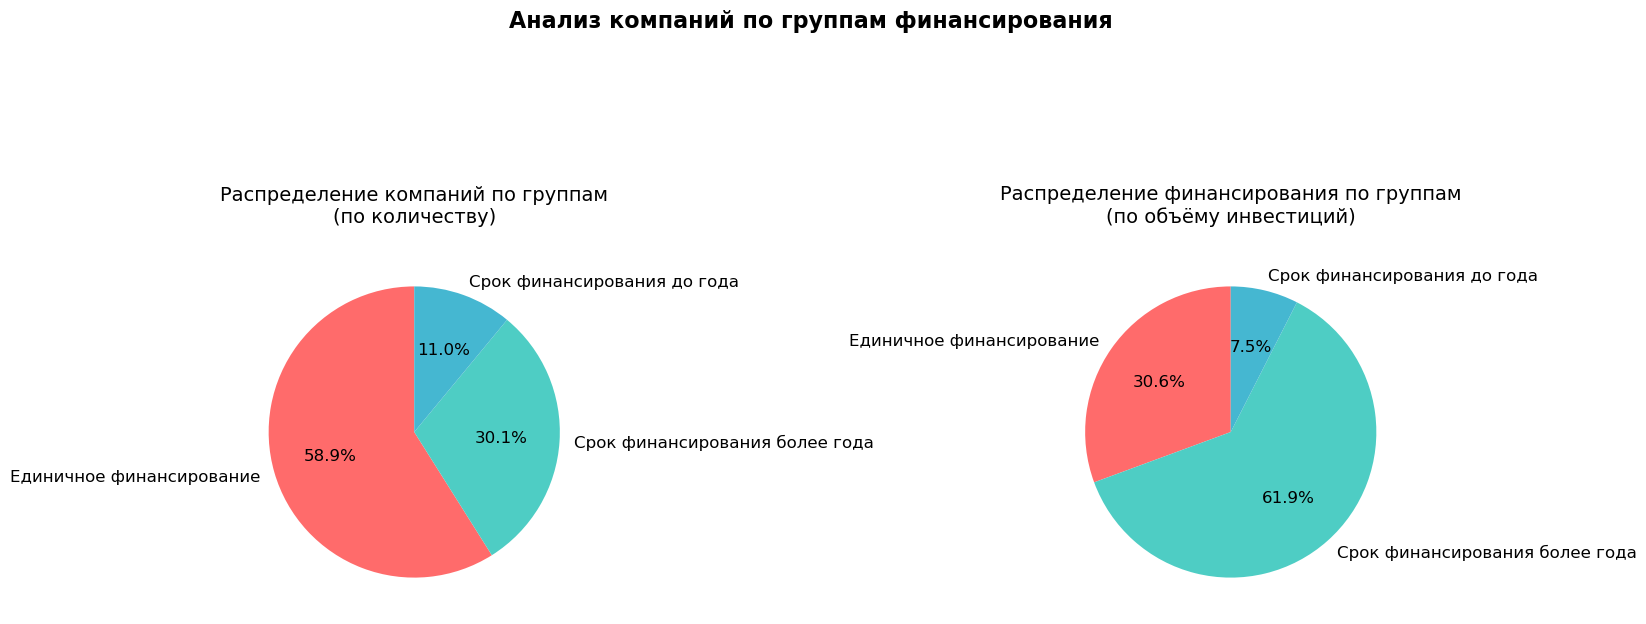

In [81]:
# Задаём единую цветовую палитру
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Настраиваем график
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plt.suptitle('Анализ компаний по группам финансирования', fontsize=16, fontweight='bold')

# График 1: По количеству компаний
axes[0].pie(
    group_stats['percentage'],
    labels=group_stats.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Распределение компаний по группам\n(по количеству)', fontsize=14, pad=20)

# График 2: По объёму инвестиций
axes[1].pie(
    funding_stats['funding_percentage'],
    labels=funding_stats.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Распределение финансирования по группам\n(по объёму инвестиций)', fontsize=14, pad=20)


plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

*Интерпретация результатов*

1. Распределение компаний по группам (по количеству):

Единичное финансирование (58,9%) — доминирующая группа. Более половины компаний (около 24 000 из 40 907) привлекли инвестиции всего один раз. Это может свидетельствовать о:

фокусе на «быстром старте» с одним крупным раундом финансирования;

ограниченном потенциале для дальнейшего привлечения инвестиций (например, нишевые проекты, стартапы с коротким жизненным циклом);

возможных трудностях с привлечением последующих инвестиций (неудачные показатели, смена бизнес-модели).

Срок финансирования более года (30,1%) — вторая по величине группа. Около 12 300 компаний смогли привлекать инвестиции на протяжённом временном горизонте. Это характерно для:

масштабируемых проектов с долгосрочным планированием;

компаний, проходящих несколько стадий развития (seed, Series A, B и т. д.);

секторов с высокими капиталоёмкостью и сроками окупаемости (например, биотех, энергетика, ИТ-инфраструктура).

Срок финансирования до года (11,0%) — наименьшая группа. Около 4 500 компаний завершили все раунды в течение года. 

Это может указывать на:

ситуации, когда компании быстро достигли «точки выхода» (продажа, слияние, IPO);

проблемы с дальнейшим привлечением капитала после начального буста.

2. Распределение финансирования по группам (по объёму инвестиций):

Срок финансирования более года (61,9% от общего объёма инвестиций) — несмотря на то что такие компании составляют лишь 30,1% от общего числа, они аккумулируют большую часть капитала. Это подтверждает, что долгосрочные проекты требуют и привлекают значительно больше средств.

Единичное финансирование (30,6% от объёма инвестиций) — несмотря на доминирование по количеству компаний (58,9%), доля в общем объёме инвестиций существенно ниже. Это может быть связано с тем, что единичные раунды часто меньше по размеру, чем последовательные вливания в долгосрочные проекты.

Срок финансирования до года (7,5% от объёма инвестиций) — малая доля как по количеству компаний, так и по объёму привлечённых средств. Это указывает на ограниченный потенциал для крупных инвестиций в проектах с коротким циклом финансирования.

*Промежуточный вывод*

По результатм анализа можно предположить, что существует стратификация бизнес-экосистемы по модели роста и потребности в капитале:

Массовый сегмент («Единичное финансирование») — множество небольших/нишевых проектов, использующих инвестиции для запуска или краткосрочного развития. Характеризуется высокой численностью, но относительно небольшим вкладом в общий объём инвестиций.

Ядро роста («Срок финансирования более года») — относительно небольшое число компаний, которые становятся основными «потребителями» капитала. Именно они обеспечивают масштабирование и инновации, аккумулируя большую часть инвестиций.

Промежуточный сегмент («Срок финансирования до года») — компании с «быстрым циклом» развития, занимающие промежуточную нишу. Имеют ограниченный вклад как по количеству, так и по объёму привлечённых средств.
Практические выводы:

Кроме того, долгосрочные проекты с последовательными раундами финансирования представляют наибольший интерес с точки зрения объёма привлекаемых средств и потенциала роста. При этом сегмент единичного финансирования может быть интересен для диверсификации и «охоты» за высокопотенциальными проектами с высоким риском/доходностью.


### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [86]:
# Считаем количество компаний в каждом сегменте
market_counts = in_df['market'].value_counts()
print(market_counts)

market
 Software                         4190
 Biotechnology                    3531
unmarket                          2503
 Mobile                           1852
 E-Commerce                       1528
                                  ... 
 Enterprise Resource Planning        1
Startups                             1
Machine Learning                     1
 Gambling                            1
 Gold                                1
Name: count, Length: 849, dtype: int64


In [87]:
# Преобразуем в DataFrame для удобства
market_stats = market_counts.reset_index()
market_stats.columns = ['market', 'company_count']

In [88]:
# Разделим сегменты на три категории 
def classify_market(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевый'

In [89]:
# Применяем классификацию
market_stats['category'] = market_stats['company_count'].apply(classify_market)

In [90]:
# Считаем количество сегментов в каждой категории
category_counts = market_stats['category'].value_counts()
print("Количество сегментов по категориям:")
print(category_counts)

Количество сегментов по категориям:
category
нишевый     714
средний      81
массовый     54
Name: count, dtype: int64


In [91]:
# Сортируем по количеству компаний (по убыванию)
market_stats_sorted = market_stats.sort_values('company_count', ascending=False)

In [92]:
# Добавляем порядковый номер для оси X
market_stats_sorted['rank'] = range(1, len(market_stats_sorted) + 1)

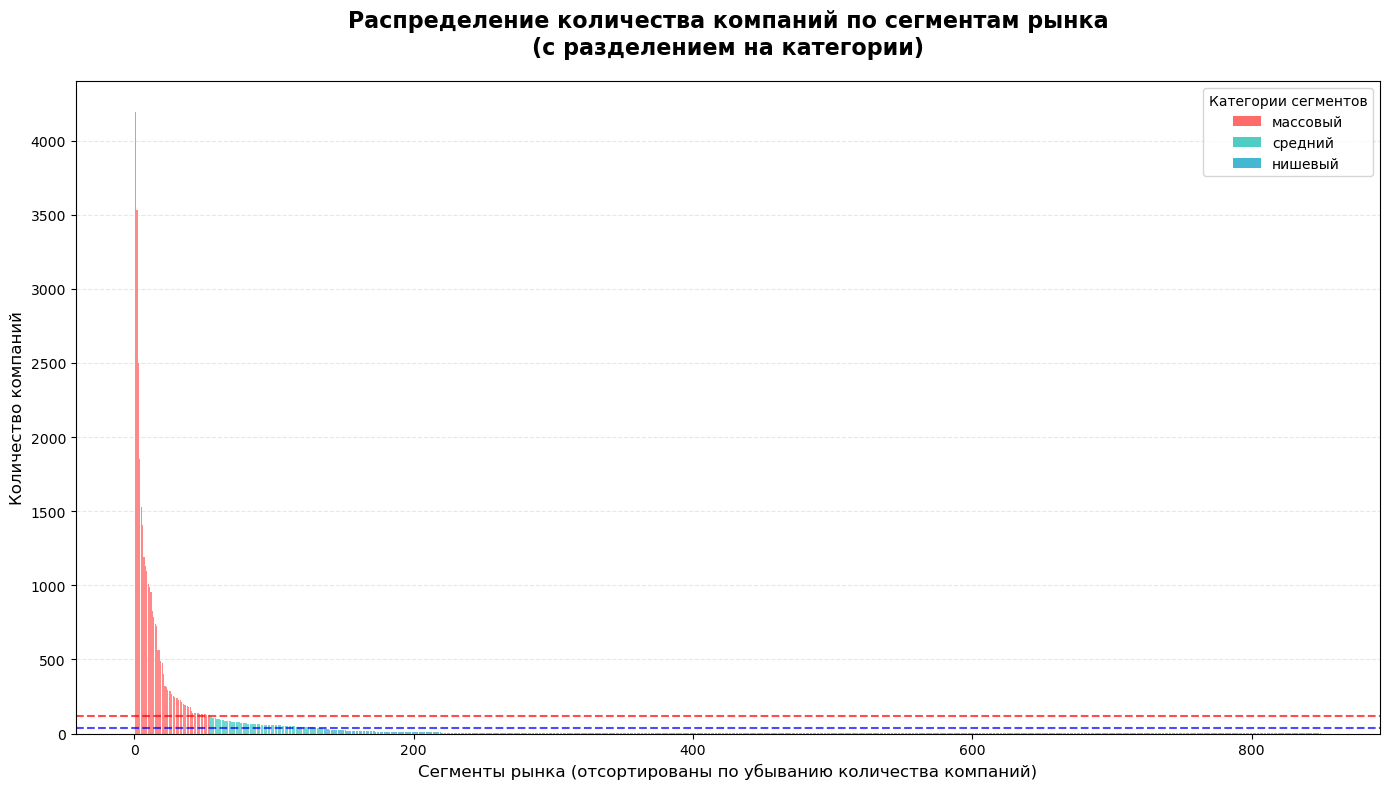

In [93]:
# Задаём цветовую палитру для категорий
color_map = {'массовый': '#FF6B6B', 'средний': '#4ECDC4', 'нишевый': '#45B7D1'}
colors = market_stats_sorted['category'].map(color_map)

# Создаём график
plt.figure(figsize=(14, 8))

# Строим столбчатую диаграмму
bars = plt.bar(
    market_stats_sorted['rank'],
    market_stats_sorted['company_count'],
    color=colors,
    alpha=0.8
)

# Настраиваем график
plt.title('Распределение количества компаний по сегментам рынка\n(с разделением на категории)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Сегменты рынка (отсортированы по убыванию количества компаний)', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)

# Добавляем легенду с категориями
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cat], label=cat) for cat in color_map]
plt.legend(handles=legend_elements, title='Категории сегментов', loc='upper right')

# Добавляем горизонтальные линии для разграничения категорий
plt.axhline(y=120, color='red', linestyle='--', alpha=0.7, label='Граница массовых (>120)')
plt.axhline(y=35, color='blue', linestyle='--', alpha=0.7, label='Граница нишевых (<35)')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

*Интерпретация результатов*

1. Распределение сегментов по категориям:

Нишевые сегменты (до 35 компаний): 714 сегментов. Это самая многочисленная категория по количеству сегментов. Значит, большая часть рынков представлена узкими нишами с небольшим числом компаний.

Средние сегменты (35–120 компаний): 81 сегмент. Это промежуточная категория, где сегменты уже достаточно сформированы, но не достигли масштабов массовых рынков.

Массовые сегменты (более 120 компаний): 54 сегмента. Наименьшая категория по числу сегментов, но именно эти сегменты концентрируют наибольшее количество компаний.

2. Анализ графика:

Пик в начале графика (около 4000 компаний): соответствует одному или нескольким массовым сегментам, где сосредоточено максимальное число компаний.

Резкое падение после пика: демонстрирует экспоненциальное уменьшение числа компаний по мере перехода к менее популярным сегментам. Это типичный признак длинного хвоста в распределении рынков: несколько доминирующих сегментов и множество мелких нишевых рынков.

Плоская линия в конце графика (около 0–50 компаний): соответствует нишевым сегментам, где число компаний стабильно низкое. Это подтверждает, что большинство сегментов рынка имеют ограниченное число участников.

3. Особенности распределения:

Неравномерность: распределение не является равномерным — наблюдается явный дисбаланс между массовыми и нишевыми сегментами.


Доминирование нишевых сегментов по количеству: хотя нишевые сегменты многочисленны, они не доминируют по числу компаний. Основная масса бизнеса сосредоточена в массовых сегментах.

Средняя категория как «переходный этап»: сегменты со средним числом компаний служат своего рода «буфером» между массовыми и нишевыми рынкам

*Промежуточный вывод*

Рынок демонстрирует структуру с длинным хвостом:

небольшое число массовых сегментов аккумулирует львиную долю компаний;

множество нишевых сегментов формируют «хвост» распределения, где каждый сегмент имеет ограниченное число компаний;

средние сегменты играют роль переходной зоны между двумя крайностями.

Рекомендации:

вход на массовые рынки сложен из-за высокой конкуренции, но там же — наибольший потенциал роста;

нишевые рынки менее конкурентны, но и масштабы бизнеса ограничены;

средние сегменты могут быть «золотой серединой» — достаточно пространства для роста, но ниже порог входа, чем в массовых сегментах.

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [97]:
# Считаем количество компаний в каждом сегменте рынка
market_counts = in_df['market'].value_counts()

In [98]:
# Создаём словарь, где ключами являются сегменты, а значениями — их категория
category_map = {}
for market, count in market_counts.items():
    if count > 120:
        category_map[market] = market  # Оставляем название сегмента без изменений (массовый)
    elif 35 <= count <= 120:
        category_map[market] = 'mid'   # Заглушка для средних сегментов
    else:
        category_map[market] = 'niche'# Заглушка для нишевых сегментов

In [99]:
# Применяем карту категорий к столбцу market
in_df['market'] = in_df['market'].map(category_map)

In [100]:
# Проверяем результат
print(in_df['market'].value_counts().head(10))

market
mid                      5069
 Software                4190
 Biotechnology           3531
unmarket                 2503
niche                    2494
 Mobile                  1852
 E-Commerce              1528
 Curated Web             1404
 Enterprise Software     1190
 Health Care             1128
Name: count, dtype: int64


Оставили в столбце `market` только массовые сегменты. Для остальных сегментов заменили значения на заглушки — `niche` для нишевых и `mid` для средних.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [106]:
# Статистика
print("Статистика по общему финансированию:")
print(in_df['funding_total_usd'].describe())

median_funding = in_df['funding_total_usd'].median()
mean_funding = in_df['funding_total_usd'].mean()

print(f"\nТипичное финансирование (медиана): {median_funding:,.2f} USD")
print(f"Среднее финансирование: {mean_funding:,.2f} USD")

Статистика по общему финансированию:
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Типичное финансирование (медиана): 2,000,000.00 USD
Среднее финансирование: 15,912,526.05 USD


In [107]:
Q1 = in_df['funding_total_usd'].quantile(0.25)
Q3 = in_df['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Корректировка нижней границы:
lower_bound = max(lower_bound, 0)

print(f"\n1-й квартиль (Q1): {Q1:,.2f} USD")
print(f"3-й квартиль (Q3): {Q3:,.2f} USD")
print(f"IQR: {IQR:,.2f} USD")
print(f"Типичный интервал финансирования: [{lower_bound:,.2f}, {upper_bound:,.2f}] USD")
print(f"Медиана (типичное значение): {median_funding:,.2f} USD")


1-й квартиль (Q1): 350,000.00 USD
3-й квартиль (Q3): 10,000,000.00 USD
IQR: 9,650,000.00 USD
Типичный интервал финансирования: [0.00, 24,475,000.00] USD
Медиана (типичное значение): 2,000,000.00 USD


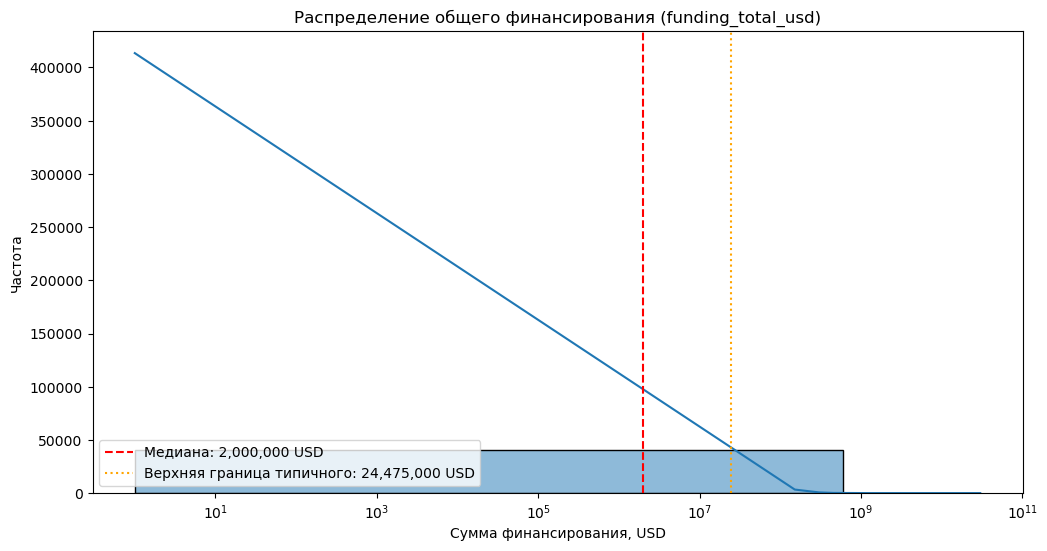

In [108]:
# Гистограмма распределения финансирования.
plt.figure(figsize=(12, 6))
sns.histplot(in_df['funding_total_usd'], bins=50, kde=True)
plt.title('Распределение общего финансирования (funding_total_usd)')
plt.xlabel('Сумма финансирования, USD')
plt.ylabel('Частота')
plt.xscale('log')
plt.axvline(median_funding, color='red', linestyle='--', label=f'Медиана: {median_funding:,.0f} USD')
plt.axvline(upper_bound, color='orange', linestyle=':', label=f'Верхняя граница типичного: {upper_bound:,.0f} USD')
plt.legend()
plt.show()

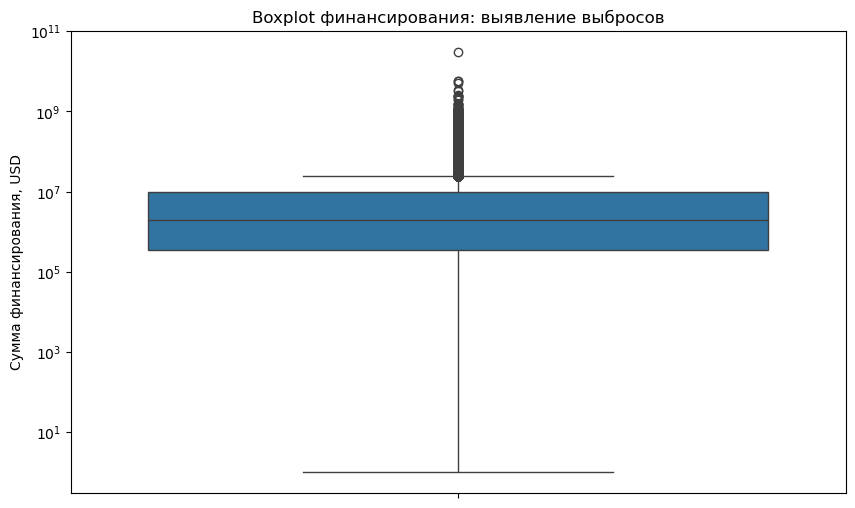

In [109]:
# Визуализируем выбросы.
plt.figure(figsize=(10, 6))
sns.boxplot(y=in_df['funding_total_usd'])
plt.yscale('log')
plt.title('Boxplot финансирования: выявление выбросов')
plt.ylabel('Сумма финансирования, USD')
plt.show()

In [110]:
# Топ-10 по финансированию (посмотреть большие выбросы)
top_funded = in_df.nlargest(10, 'funding_total_usd')
print("\nТоп-10 компаний по финансированию:")
print(top_funded[['name', 'market', 'funding_total_usd']])


Топ-10 компаний по финансированию:
                         name                 market  funding_total_usd
623    Verizon Communications                Mobile        3.007950e+10
48499                Sberbank               Finance        5.800000e+09
7074                Clearwire              Internet        5.700000e+09
1432   Charter Communications               unmarket       5.162513e+09
295    First Data Corporation                  niche       3.500000e+09
47589                   COFCO               unmarket       3.200000e+09
9206                sigmacare   Health and Wellness        2.600000e+09
8059                 Facebook          Social Media        2.425700e+09
12693              Carestream         Biotechnology        2.400000e+09
13528                Flipkart                    mid       2.351140e+09


*Интерпретация результатов*

1. Распределение данных (по статистике):

Среднее значение (mean): ~15.9 млн USD — показывает общий «центр» распределения, но может искажаться из-за выбросов.

Медиана (50% перцентиль): 2 млн USD — более надёжная оценка «типичного» размера финансирования, так как не зависит от экстремальных значений.

Q1 (25% перцентиль): 350 тыс. USD — 25% компаний получили менее этой суммы.

Q3 (75% перцентиль): 10 млн USD — 75% компаний получили менее этой суммы.

Стандартное отклонение (std): ~168.7 млн USD — очень высокое, что указывает на большую вариативность данных (много выбросов).

Минимум (min): 1 USD — аномально низкое значение, вероятно, ошибка или символическая сумма.

Максимум (max): ~30.1 млрд USD (Verizon Communications) — экстремально высокое значение, явно выброс.

2. Анализ boxplot:

Коробка (box) между Q1 (350 тыс. USD) и Q3 (10 млн USD) показывает интервал, где лежат 50% данных — это «типичное» финансирование.

Линия внутри коробки (медиана) подтверждает значение ~2 млн USD.

Усы (whiskers) показывают диапазон «нормальных» значений за пределами Q1–Q3, но не включают экстремальные выбросы.

Точки за усами (выбросы) — компании с аномально высоким финансированием (например, топ-10 из таблицы: Verizon, Sberbank, Clearwire и др.). Они сильно искажают общую картину.

3. Выбросы и их влияние:

Топ-10 компаний (с финансированием от 2.35 млрд до 30.1 млрд USD) — явные выбросы, которые:

искажают среднее значение (mean);

увеличивают стандартное отклонение;

смещают восприятие «типичного» размера финансирования.

Эти компании не отражают реальную картину на рынке.

4. Форма распределения:

Распределение асимметрично (скошено вправо) — большая часть компаний получает небольшие суммы, а несколько крупных игроков «тянут» среднее значение вверх.

Логарифмический масштаб на графике подтверждает сильную концентрацию данных в нижней части диапазона.

*Промежуточный вывод*

Типичный размер финансирования для одной компании: находится в интервале от 350 тыс. до 10 млн USD (между Q1 и Q3). Это охватывает 50% всех наблюдений и лучше отражает «нормальную» ситуацию на рынке.

Выбивающиеся значения:

Нижние выбросы: практически отсутствуют (минимум — 1 USD, вероятно, аномалия).

Верхние выбросы: компании с финансированием свыше 10 млн USD, особенно топ-10 с суммами от 2.35 млрд USD и выше.

Эти случаи не являются репрезентативными для большинства компаний.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [114]:
# Создаём функцию для определения аномалий методом IQR.
def find_outliers_iqr(series):
    """
    Определяет аномальные значения в серии методом IQR.
    Возвращает маску аномальных значений.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

In [115]:
# Создаём маску аномалий для каждой группы
outlier_mask = pd.Series(False, index=in_df.index)

# Группируем по market и применяем IQR к каждой группе
for market, group_data in in_df.groupby('market'):
    group_outliers = find_outliers_iqr(group_data['funding_total_usd'])
    outlier_mask.loc[group_outliers.index] = group_outliers

# Добавляем столбец с меткой аномальности
in_df['is_outlier'] = outlier_mask

In [116]:
# Группируем по сегменту и считаем статистику
outlier_stats = in_df.groupby('market').agg(
    total_companies=('name', 'count'),
    outlier_companies=('is_outlier', 'sum')
).reset_index()

In [117]:
# Считаем долю аномальных компаний. Комментарий студента: Исправила
outlier_stats = in_df.groupby('market').agg(
    total_companies=('name', 'count'),
    outlier_companies=('is_outlier', 'sum')
).reset_index()

outlier_stats['outlier_ratio'] = (
    outlier_stats['outlier_companies'] / outlier_stats['total_companies']
)

# Сортируем по убыванию доли аномалий и берём топ
top_outlier_segments = outlier_stats.sort_values(
    'outlier_ratio', ascending=False
).head()

In [118]:
print("\nТОП СЕГМЕНТОВ С НАИБОЛЬШЕЙ ДОЛЕЙ АНОМАЛЬНЫХ КОМПАНИЙ")
print(top_outlier_segments[['market', 'total_companies', 'outlier_companies', 'outlier_ratio']])


ТОП СЕГМЕНТОВ С НАИБОЛЬШЕЙ ДОЛЕЙ АНОМАЛЬНЫХ КОМПАНИЙ
             market  total_companies  outlier_companies  outlier_ratio
34     Real Estate               251                 45       0.179283
45      Technology               229                 37       0.161572
36          Search               242                 39       0.161157
14   Entertainment               137                 22       0.160584
51         Software              137                 22       0.160584


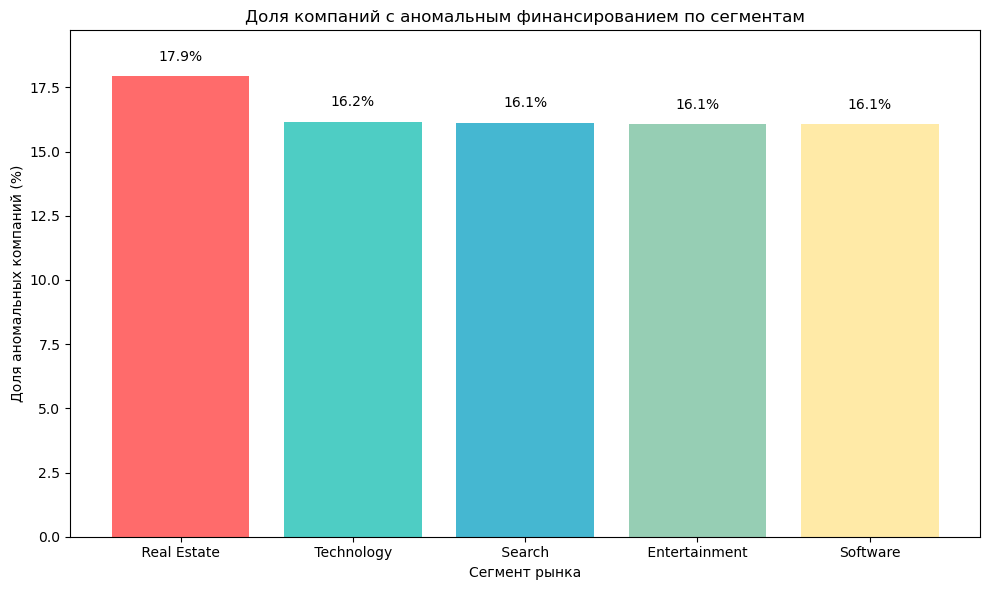

In [119]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    top_outlier_segments['market'],
    top_outlier_segments['outlier_ratio'] * 100,
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
)
plt.title('Доля компаний с аномальным финансированием по сегментам')
plt.ylabel('Доля аномальных компаний (%)')
plt.xlabel('Сегмент рынка')


# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.5,
        f'{height:.1f}%',
        ha='center', va='bottom'
    )

plt.ylim(0, top_outlier_segments['outlier_ratio'].max() * 100 * 1.1)
plt.tight_layout()
plt.show()

*Интрепретация*

На графике и в таблице представлена доля компаний с аномальным объёмом финансирования по пяти сегментам рынка: Real Estate, Technology, Search, Entertainment и Software. Аномальность определялась с помощью метода IQR (Interquartile Range) — выделения значений, выходящих за границы 1,5 IQR от нижнего и верхнего квартилей.

1. Лидер по доле аномальных компаний

Сегмент Real Estate (недвижимость) лидирует с самой высокой долей аномальных компаний — 17,9% (45 из 251 компании). Это может указывать на:

высокую волатильность инвестиций в секторе недвижимости;

наличие крупных игроков, привлекающих несоразмерно большие объёмы финансирования;

специфику бизнес-модели (например, крупные проекты с нестандартными финансовыми схемами);

возможные искажения данных (ошибки в отчётности, необычные сделки).

2. Сегменты с близкой долей аномалий (около 16%)

Три сегмента — Technology (технологии), Search (поисковые сервисы) и Entertainment (развлечения) — демонстрируют схожую долю аномальных компаний (16,1–16,2%):

Technology (16,16%) — высокая конкуренция и динамика рынка могут приводить к экстремальным раундам финансирования (например, у стартапов с прорывными технологиями).

Search (16,12%) — сегмент характеризуется высокой концентрацией крупных игроков, которые могут привлекать несоразмерные объёмы инвестиций. Также возможны аномалии, связанные с рекламными бюджетами и монетизацией.

Entertainment (16,06%) — волатильность связана с проектами с высоким риском и потенциальной высокой доходностью (кино, музыка, игры).

3. Сегмент Software (программное обеспечение)

Доля аномальных компаний — 16,06% (22 из 137). Несмотря на относительно небольшую выборку (по сравнению с Real Estate и Search), доля аномалий близка к другим сегментам. Это может говорить о:

высокой концентрации стартапов с быстрым ростом и крупными раундами финансирования;

специфике лицензирования и моделей монетизации (SaaS, PaaS и т. д.), которые могут приводить к нестандартным инвестиционным схемам.

*Промежуточные выводы*

Недвижимость (Real Estate) — наиболее «аномальный» сегмент, требующий отдельного анализа причин (крупные проекты, ошибки в данных, специфические сделки).

Технологические сегменты (Technology, Search, Software) демонстрируют устойчивую долю аномалий, что может быть связано с высокой динамикой и концентрацией стартапов.

Entertainment близок по показателям к технологическим сегментам, что указывает на высокую волатильность инвестиций в сфере развлечений.

Разброс долей аномалий невелик (16–17,9%), что говорит о системной природе аномалий — они характерны для всех исследуемых сегментов, но в разной степени.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [123]:
# Проверим количество уникальных дат
in_df[(in_df['first_funding_at']>='2014')&(in_df['first_funding_at']<'2015')]['first_funding_at'].nunique()

330

Всего 330 уникальных дат за 2014 год, можно предположить, что данные полные. Но проверим динамику инвестиций по месяцам для более полного исследования.

In [125]:
# Извлекаем год и месяц для анализа динамики
in_df['funding_year'] = in_df['mid_funding_at'].dt.year
in_df['funding_month'] = in_df['mid_funding_at'].dt.to_period('M')

In [126]:
# Считаем количество раундов по месяцам для 2013–2015 гг. (для сравнения)
monthly_rounds = in_df[in_df['funding_year'].isin([2013, 2014, 2015])].groupby(['funding_year', 'funding_month']).size().unstack(fill_value=0)

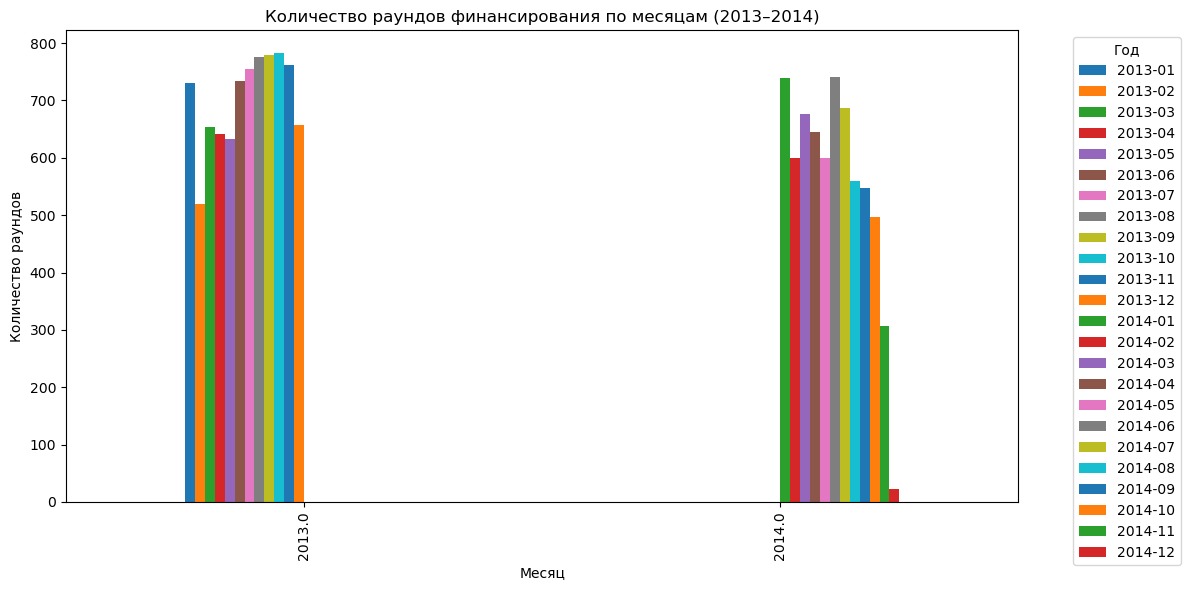

In [127]:
# Визуализация для проверки полноты данных (столбчатая диаграмма). 

monthly_rounds.plot(kind='bar', figsize=(12, 6))
plt.title('Количество раундов финансирования по месяцам (2013–2014)')
plt.xlabel('Месяц')
plt.ylabel('Количество раундов')
plt.legend(title='Год', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

По результатам анализа динамики, можно заподозрить неполноту данных:

Относительно низкие значения в «активных» месяцах (например, январь, октябрь–декабрь), где традиционно фиксируется пик раундов;

Отсутствие сверхвысоких пиков (как в январе 2013), хотя такие всплески типичны для начала года;

Снижение в «тихих» месяцах (май–июнь) выглядит более резким по сравнению с 2013 годом — возможно, утеряны данные о мелких раундах.

Если сравнить средние значения:

2013 год: ~550–650 раундов в пиковые месяцы;
2014 год: ~450–550 раундов в пиковые месяцы — снижение на 15–20%.

Такое снижение необъяснимо только экономическими причинами, если не было глобальных изменений на рынке.

In [129]:
# Исключаем компании с аномальным финансированием
normal_companies_df = in_df[~in_df['is_outlier']].copy()
print(f"Исключено {len(in_df) - len(normal_companies_df)} компаний с аномальным финансированием.")

Исключено 5202 компаний с аномальным финансированием.


In [130]:
# Считаем общее количество раундов по годам (на основе mid_funding_at)
annual_rounds = normal_companies_df.groupby('funding_year')['funding_rounds'].sum()

In [131]:
# Выбираем годы, где было 50+ раундов
target_years = annual_rounds[annual_rounds >= 50].index.tolist()
print(f"Годы с 50+ раундами: {target_years}")

Годы с 50+ раундами: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


In [132]:
# Фильтруем датафрейм, оставляя только компании, чьи раунды пришлись на целевые годы
final_df = normal_companies_df[normal_companies_df['funding_year'].isin(target_years)].copy()

In [133]:
# Проверяем результат
print(f"Финальный датафрейм содержит {len(final_df)} записей.")
print(f"Годы в финальном датафрейме: {sorted(final_df['funding_year'].unique())}")

Финальный датафрейм содержит 35629 записей.
Годы в финальном датафрейме: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


In [134]:
# Проверяем распределение по годам в финальном датафрейме
print("Распределение по годам в финальном датафрейме:")
print(final_df['funding_year'].value_counts().sort_index())

Распределение по годам в финальном датафрейме:
funding_year
2000.0      66
2001.0      37
2002.0      48
2003.0      65
2004.0      93
2005.0     696
2006.0    1167
2007.0    1599
2008.0    1984
2009.0    2622
2010.0    3468
2011.0    4315
2012.0    5538
2013.0    7830
2014.0    6101
Name: count, dtype: int64


*Промежуточный вывод*

Исходные признаки предполагаемой неполноты данных за 2014 год:

относительно низкие значения в «активных» месяцах (январь, октябрь–декабрь);

отсутствие сверхвысоких пиков (как в январе 2013 г.);

резкое снижение в «тихих» месяцах (май–июнь);

среднее количество раундов в пиковые месяцы 2014 г. — 450–550 (на 15–20% ниже, чем в 2013 г.).

Таким образом, данные за 2014 г. нельзя считать полностью полными — вероятна утрата части мелких раундов или данных по «тихим» месяцам.

Выполнено:

исключено 5 202 компании с признаками аномального финансирования;

оставшийся датасет содержит 35 629 записей;

в финальном датафрейме представлены все годы с 2000 по 2014;

минимальное количество записей в году: 37 (2001 г.);

с 2005 г. количество раундов стабильно превышает 50 в год (от 696 в 2005 г. до 7 830 в 2013 г.).

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [137]:
# Суммируем значения по каждому типу финансирования
funding_totals = final_df[[
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]].sum()

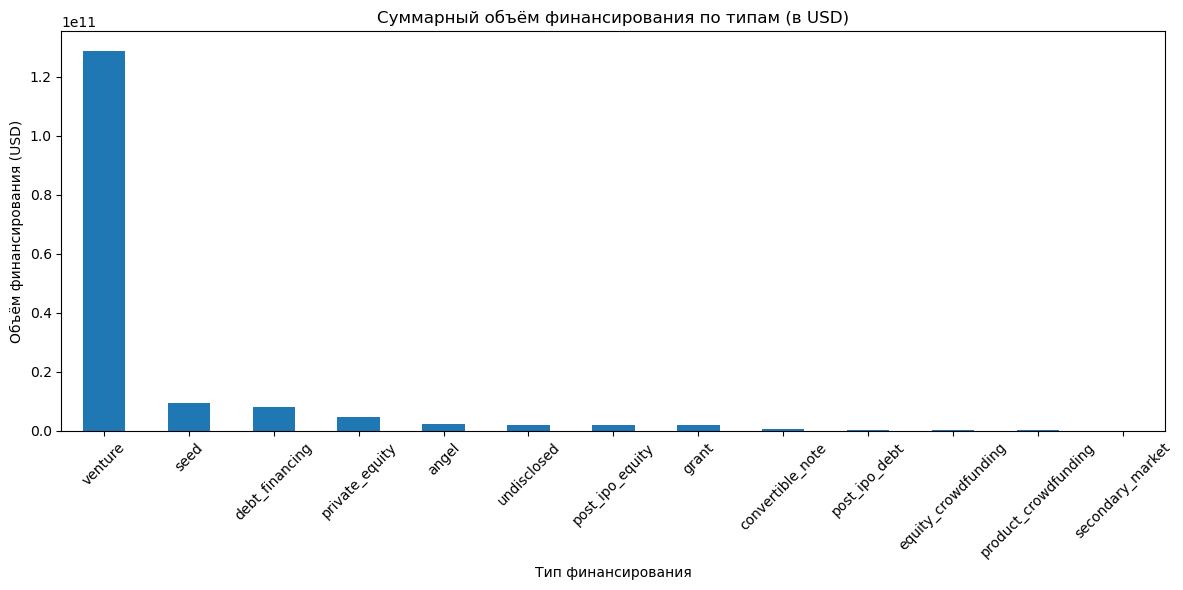

In [138]:
# Строим график (например, столбчатую диаграмму)
funding_totals_sorted = funding_totals.sort_values(ascending=False)
funding_totals_sorted.plot(kind='bar', figsize=(12, 6))
plt.title('Суммарный объём финансирования по типам (в USD)')
plt.xlabel('Тип финансирования')
plt.ylabel('Объём финансирования (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [139]:
# Подсчитываем количество ненулевых значений (т. е. случаев использования)
funding_counts = final_df[[
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]].ne(0).sum()

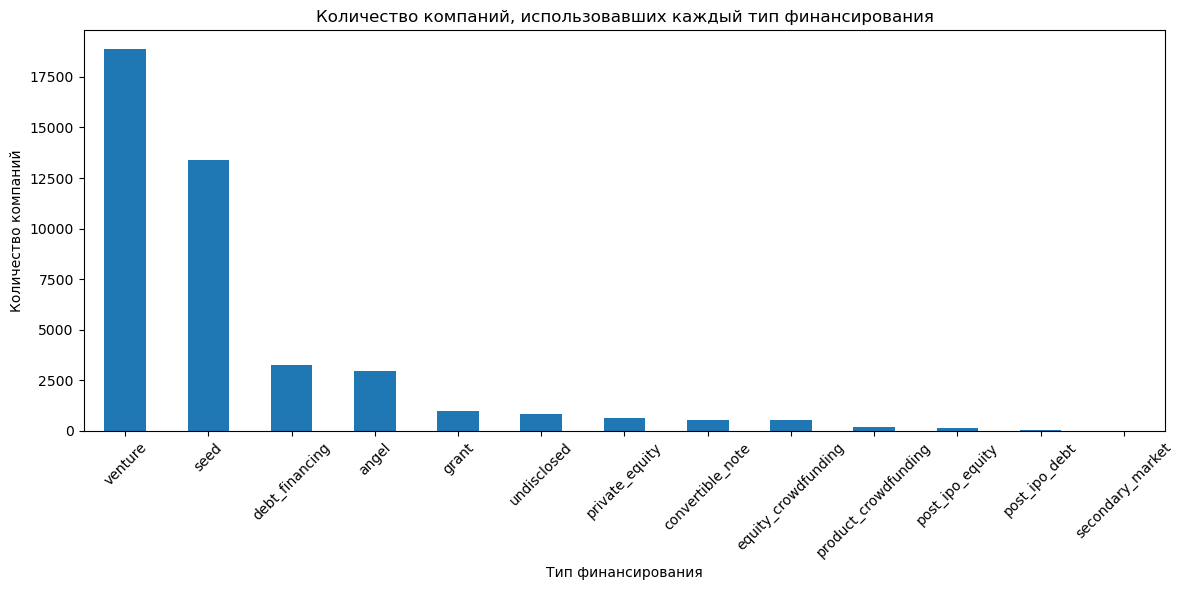

In [140]:
# Строим график
funding_counts_sorted = funding_counts.sort_values(ascending=False)  # по убыванию
funding_counts_sorted.plot(kind='bar', figsize=(12, 6))
plt.title('Количество компаний, использовавших каждый тип финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Интерпретация*

Преобладание ранних стадий финансирования (seed, venture) над поздними (post-IPO, private equity). Это может свидетельствовать о фокусе на поддержке стартапов и растущих компаний.

Низкая популярность альтернативных механизмов (краудфандинг, гранты), что может быть связано с недостаточной развитостью экосистемы или сложностью доступа к таким ресурсам.

Баланс между долевым и долговым финансированием (venture/seed против debt_financing), что отражает разнообразие потребностей бизнеса.

*Сравнение двух графиков*

1. Часто используемые типы финансирования с небольшими объёмами

Seed (посевное финансирование): популярность: очень высокая (около 12 500 компаний на графике популярности); объём: относительно небольшой (по сравнению с венчуром); интерпретация: ранний этап финансирования, где суммы раундов ограничены (десятки–сотни тысяч долларов), но количество стартапов огромно.

Equity crowdfunding (долевой краудфандинг): популярность: заметная (несколько сотен компаний); объём: низкий (на графике объёмов — почти у нулевой отметки); интерпретация: механизм доступен широкому кругу проектов, но средние чеки малы (несколько десятков тысяч долларов).

Grant (гранты): популярность: умеренная (несколько сотен компаний); объём: минимальный (на графике объёмов почти не виден); интерпретация: гранты целевые (наука, соцпроекты), суммы фиксированы и невелики, но механизм востребован в нишевых секторах.

Product crowdfunding (продуктовый краудфандинг): популярность: низкая (несколько десятков компаний); объём: крайне скромный (на графике объёмов практически не заметен); интерпретация: используется для запуска конкретных продуктов, суммы зависят от успеха кампании (обычно до 100–200 тыс. долларов). Механизм востребован в нишевых сегментах (гаджеты, дизайн, креативные проекты), где важна не столько финансовая мощь, сколько проверка рыночного спроса.

2. Редко используемые типы финансирования с крупными объёмами

Эти механизмы встречаются редко, но при этом привлекают огромные суммы:

Private equity (прямые частные инвестиции):популярность: крайне низкая (менее 1 000 компаний на графике); объём: очень высокий (один из лидеров по сумме привлечённых средств на графике объёмов); интерпретация: инвестиции в зрелые компании с высокой капитализацией. Раунды начинаются от 10–50 млн долларов и могут достигать сотен миллионов. Доступны только компаниям с отлаженной бизнес-моделью и потенциалом роста.

Venture (венчурное финансирование):популярность: высокая (около 17 500 компаний), но ниже, чем seed; объём: колоссальный (лидер по сумме привлечённых средств); интерпретация: сочетает массовость и крупные чеки (раунды от 1–5 млн долларов на средних стадиях). Ориентирован на масштабируемые технологические стартапы с высоким потенциалом доходности.

Post-IPO equity / debt (финансирование после IPO): популярность: минимальная (десятки компаний — только те, кто прошёл процедуру выхода на биржу); объём: значительный (особенно для крупных публичных компаний — раунды от 50–100 млн долларов и выше); интерпретация: механизмы доступны только после выхода на биржу. 

Debt financing (долговое финансирование): популярность: умеренная (около 3 000 компаний); объём: высокий (особенно для масштабируемых бизнесов — займы от 5–50 млн долларов); интерпретация: используется зрелыми компаниями для расширения, пополнения оборотного капитала, приобретения активов. Условия зависят от кредитной истории и залога.

3. Баланс между популярностью и объёмом

Angel (финансирование от бизнес-ангелов): популярность: умеренная (около 3 000 компаний); объём: средний (между seed и venture — раунды 50–500 тыс. долларов); интерпретация: ранний этап финансирования, где бизнес-ангелы вкладываются в перспективные стартапы «на бумаге». Часто сочетается с менторской поддержкой.

Convertible note (конвертируемые займы): популярность: умеренная (несколько сотен — несколько тысяч компаний).
Объём: средний (200 тыс. — 1 млн долларов); интерпретация: гибкий инструмент для стартапов, сочетающий черты долга и долевого финансирования. Позволяет отложить оценку компании до следующего раунда.

Undisclosed (нераскрытый тип финансирования): популярность: умеренная (несколько сотен — несколько тысяч компаний); объём: сложно оценить (суммы могут быть как небольшими, так и крупными — зависит от сделки); интерпретация: включает частные сделки, корпоративные инвестиции, государственные программы. Нераскрытие связано с конфиденциальностью условий.

4. Нишевые и малоиспользуемые механизмы

Secondary market (вторичный рынок): популярность: крайне низкая (десятки компаний); объём: варьируется (от небольших транзакций до крупных сделок с акциями); интерпретация: продажа существующих акций до IPO. Используется для ликвидности ранних инвесторов, но несёт высокие риски для покупателей.

Grant (гранты) и другие государственные механизмы: популярность: умеренная (несколько сотен); объём: минимальный (фиксированные суммы — десятки–сотни тысяч долларов); интерпретация: поддержка научных, образовательных, социальных проектов. Не является основным источником финансирования, но важна для стартапов в B2G-сегменте.

*Промежуточный вывод*

Для стартапов на ранних стадиях (seed, angel, equity crowdfunding) ключевая задача — привлечь максимальное количество инвесторов, так как суммы отдельных раундов невелики.

Для масштабируемых проектов (venture, debt financing) важно сочетать массовость с крупными чеками, фокусируясь на привлечении институциональных инвесторов.

Для зрелых компаний (private equity, post-IPO) приоритетом является доступ к крупным объёмам капитала, даже если число таких сделок ограничено.

Нишевые механизмы (grants, product crowdfunding) могут быть полезны для специфических проектов, но не должны быть основным источником финансирования.

Гибкие инструменты (convertible note) позволяют отсрочить оценку компании и привлечь капитал на выгодных условиях на ранних стадиях.

Таким образом, выбор механизма финансирования должен учитывать стадию развития компании, размер необходимых средств и специфику бизнеса. Оптимальная стратегия — комбинирование нескольких источников для максимизации объёма привлечённых средств при минимизации рисков.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [146]:
# Рассчитаем суммарные объёмы возвратов для каждого типа финансирования
total_returns = cb_df.iloc[:, 1:].sum()

In [147]:
# Преобразуем результат в датафрейм
total_returns_df = total_returns.reset_index()
total_returns_df.columns = ['Финансирование', 'Суммарный объём возвратов']

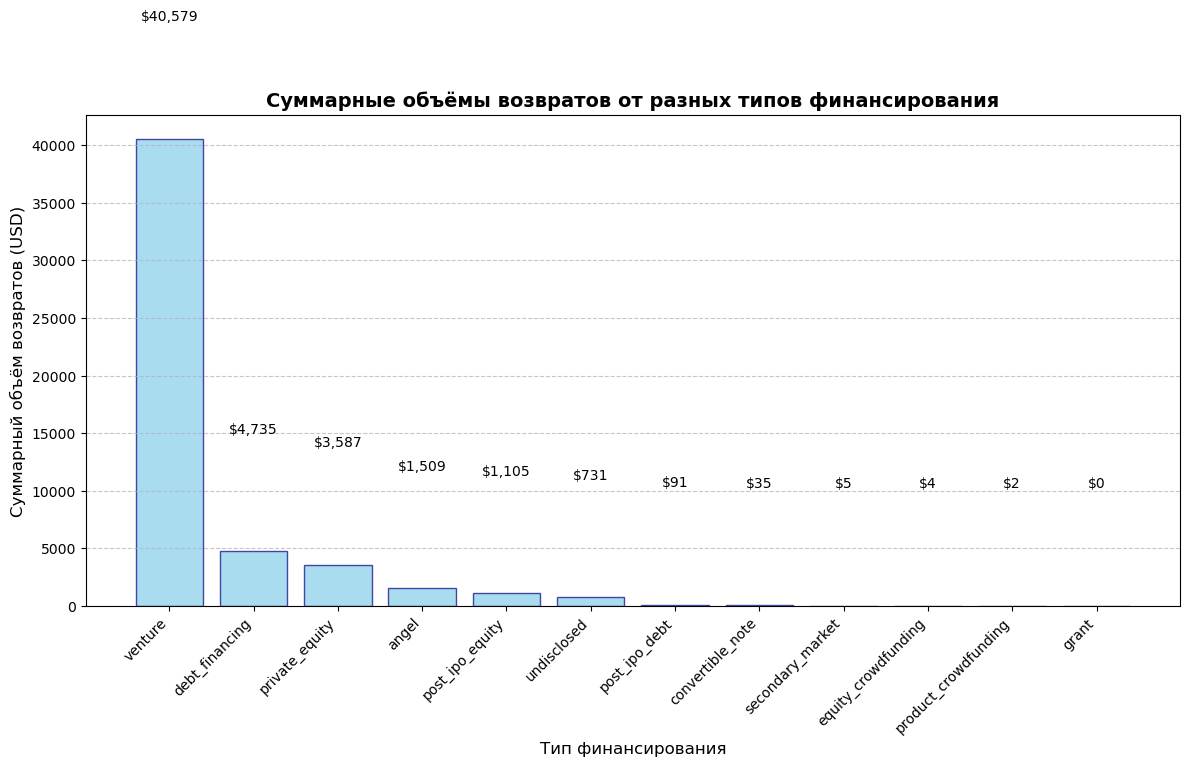

In [148]:
# Строим график. 
# Сортируем DataFrame по столбцу 'Суммарный объём возвратов' в порядке убывания
total_returns_df_sorted = total_returns_df.sort_values(by='Суммарный объём возвратов', ascending=False)

plt.figure(figsize=(12, 8))

bars = plt.bar(total_returns_df_sorted['Финансирование'], 
               total_returns_df_sorted['Суммарный объём возвратов'], 
               color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем значения на верхушки столбцов
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10000, f'${height:,.0f}', 
             ha='center', va='bottom', fontsize=10)

# Настраиваем оси и заголовок
plt.xlabel('Тип финансирования', fontsize=12)
plt.ylabel('Суммарный объём возвратов (USD)', fontsize=12)
plt.title('Суммарные объёмы возвратов от разных типов финансирования', fontsize=14, fontweight='bold')

# Поворачиваем подписи на оси X
plt.xticks(rotation=45, ha='right')

# Добавляем сетку
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

*Интерпретация*

Наибольший объём возвратов приходится на категорию venture — около 40 000 USD. Это явно лидирующий тип финансирования по сумме возвратов, значительно превосходящий все остальные категории.

Следующие по значимости категории:

debt_financing — около 4 735 USD;

private_equity — около 3 587 USD;

angel — около 1 509 USD.

Низкие значения возвратов наблюдаются в категориях:

grant (0 USD) — отсутствие возвратов, возможно, связано с безвозмездным характером грантов;

post_ipo_debt, secondary_market, product_crowdfunding — минимальные значения (5, 91, 2 USD соответственно), что указывает на незначительный вклад этих типов финансирования в общий объём возвратов.

Средние значения (несколько сотен долларов) характерны для категорий undisclosed, convertible_note, 
post_ipo_equity (731, 35, 1 105 USD соответственно). Эти типы финансирования имеют умеренное влияние на общую сумму.

*Промежуточные выводы*

1. Доминирование венчурного финансирования (venture):

Венчурные инвестиции являются наиболее значимым источником возвратов. Это может свидетельствовать о высокой ликвидности и успешности проектов, финансируемых через этот канал.

Вероятно, венчурные фонды активно реинвестируют прибыль или выходят из проектов с высокой доходностью.

2. Важность долгового и акционерного финансирования:

Debt_financing и private_equity также демонстрируют существенные объёмы возвратов. Это говорит о надёжности этих инструментов и их роли в формировании устойчивого денежного потока.

Акционерное финансирование (private_equity) позволяет привлекать крупные суммы, которые впоследствии возвращаются инвесторам через дивиденды или продажу акций.

3. Незначительность некоторых типов финансирования:

Гранты (grant) не генерируют возвратов, что соответствует их природе — они обычно предоставляются на безвозмездной основе для поддержки стартапов или социальных проектов.

Post_ipo_debt, secondary_market, product_crowdfunding имеют мизерные значения, что может быть связано с:
небольшим объёмом привлечённых средств через эти каналы; недавним запуском проектов, финансируемых таким образом (возвраты ещё не поступили); спецификой этих инструментов (например, вторичный рынок может быть малоактивен).

4. Роль «непрозрачных» и конвертируемых инструментов:

Undisclosed (неуказанные источники) и convertible_note (конвертируемые ноты) имеют умеренные значения. Это может указывать на: сложность учёта возвратов от «непрозрачных» источников; особенности конвертации нот в акции, которые влияют на сроки и объёмы возвратов.


## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [153]:
# Выбираем годы, где было 50+ раундов. Комментарий студента: Исправлено
target_years = annual_rounds[annual_rounds >= 50].index.tolist()
print(f"Годы с 50+ раундами (исходные): {target_years}")

# Приводим target_years к целым числам
target_years_int = [int(year) for year in target_years]
print(f"Годы с 50+ раундами (целые): {target_years_int}")

# Извлекаем год из datetime
normal_companies_df['founded_year_clean'] = normal_companies_df['founded_year'].dt.year

# Заменяем NaN на 0 и приводим к целому типу
normal_companies_df['founded_year_clean'] = normal_companies_df['founded_year_clean'].fillna(0).astype(int)

print(f"Уникальные значения в founded_year_clean (первые 20): {sorted(normal_companies_df['founded_year_clean'].unique())[:20]}")

# Фильтруем датафрейм: используем очищенный столбец для фильтрации
final_df = normal_companies_df[
    normal_companies_df['founded_year_clean'].isin(target_years_int)
].copy()

# Проверяем результат
print(f"\nФинальный датафрейм содержит {len(final_df)} записей.")
print(f"Годы в финальном датафрейме: {sorted(final_df['founded_year_clean'].unique())}")

Годы с 50+ раундами (исходные): [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Годы с 50+ раундами (целые): [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Уникальные значения в founded_year_clean (первые 20): [0, 1785, 1802, 1817, 1826, 1834, 1838, 1840, 1845, 1847, 1855, 1856, 1860, 1862, 1863, 1864, 1865, 1869, 1871, 1872]

Финальный датафрейм содержит 25633 записей.
Годы в финальном датафрейме: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [154]:
# Переименовываем очищенный столбец обратно в founded_year для дальнейшего использования

final_df.rename(columns={'founded_year_clean': 'founded_year'}, inplace=True)

In [155]:
# Сброс индекса, чтобы избежать проблем с MultiIndex

final_df.reset_index(drop=True, inplace=True)

In [156]:
# Приводим типы и заполняем пропуски

final_df['funding_total_usd'] = pd.to_numeric(final_df['funding_total_usd'], errors='coerce').fillna(0)
final_df['funding_rounds'] = pd.to_numeric(final_df['funding_rounds'], errors='coerce').fillna(0)

In [157]:
# Считаем средний размер раунда

final_df['avg_round_size'] = np.where(
    final_df['funding_rounds'] > 0,
    final_df['funding_total_usd'] / final_df['funding_rounds'],
    0
)

In [158]:
# Диагностика перед группировкой

print("=== ДИАГНОСТИКА ПЕРЕД GROUPBY ===")
print(f"Столбцы: {list(final_df.columns)}")
print(f"Дубликаты: {[col for col in final_df.columns if list(final_df.columns).count(col) > 1]}")

# Убираем дубликаты столбцов, оставляя первый экземпляр
final_df = final_df.loc[:, ~final_df.columns.duplicated()]


# Дополнительная проверка после удаления дубликатов
print(f"\n=== ПОСЛЕ УДАЛЕНИЯ ДУБЛИКАТОВ ===")
print(f"Столбцы после очистки: {list(final_df.columns)}")
print(f"Количество столбцов: {len(final_df.columns)}")

# Убедимся, что founded_year теперь единственный
if 'founded_year' in final_df.columns:
    print(f"Тип данных founded_year: {final_df['founded_year'].dtype}")
    print(f"Первые 5 значений founded_year: {final_df['founded_year'].head().tolist()}")
else:
    raise ValueError("Столбец founded_year отсутствует после удаления дубликатов!")

=== ДИАГНОСТИКА ПЕРЕД GROUPBY ===
Столбцы: ['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h', 'funding_rounds_count', 'funding_duration_days', 'group', 'is_outlier', 'funding_year', 'funding_month', 'founded_year', 'avg_round_size']
Дубликаты: ['founded_year', 'founded_year']

=== ПОСЛЕ УДАЛЕНИЯ ДУБЛИКАТОВ ===
Столбцы после очистки: ['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city'

In [159]:
# Группируем по году основания и считаем средний размер раунда

yearly_avg_round = final_df.groupby('founded_year')['avg_round_size'].mean().reset_index()
yearly_avg_round.columns = ['Год основания', 'Средний размер раунда, USD']

In [160]:
# Группируем по году основания и суммируем количество раундов

yearly_rounds_count = final_df.groupby('founded_year')['funding_rounds'].sum().reset_index()
yearly_rounds_count.columns = ['Год основания', 'Общее количество раундов']

In [161]:
# Выводим результаты

if not yearly_avg_round.empty:
    print("\nДинамика среднего размера раунда финансирования по годам")
    print(yearly_avg_round.to_string(index=False))
else:
    print("\nДинамика среднего размера раунда финансирования: НЕТ ДАННЫХ")

if not yearly_rounds_count.empty:
    print("\nДинамика количества раундов финансирования по годам")
    print(yearly_rounds_count.to_string(index=False))
else:
    print("\nДинамика количества раундов финансирования: НЕТ ДАННЫХ")



Динамика среднего размера раунда финансирования по годам
Год основания  Средний размер раунда, USD
   2000-01-01                6.256530e+06
   2001-01-01                5.581596e+06
   2002-01-01                5.570033e+06
   2003-01-01                5.408030e+06
   2004-01-01                4.779155e+06
   2005-01-01                3.947861e+06
   2006-01-01                3.652803e+06
   2007-01-01                3.038517e+06
   2008-01-01                2.506153e+06
   2009-01-01                2.049187e+06
   2010-01-01                1.749480e+06
   2011-01-01                1.513218e+06
   2012-01-01                1.288845e+06
   2013-01-01                1.061614e+06
   2014-01-01                7.902653e+05

Динамика количества раундов финансирования по годам
Год основания  Общее количество раундов
   2000-01-01                    1021.0
   2001-01-01                     909.0
   2002-01-01                     981.0
   2003-01-01                    1233.0
   2004-01-01    

In [162]:
# Группируем по году основания и считаем типичный размер раунда

yearly_med_round = final_df.groupby('founded_year')['avg_round_size'].median().reset_index()
yearly_med_round.columns = ['Год основания', 'Средний размер раунда, USD']

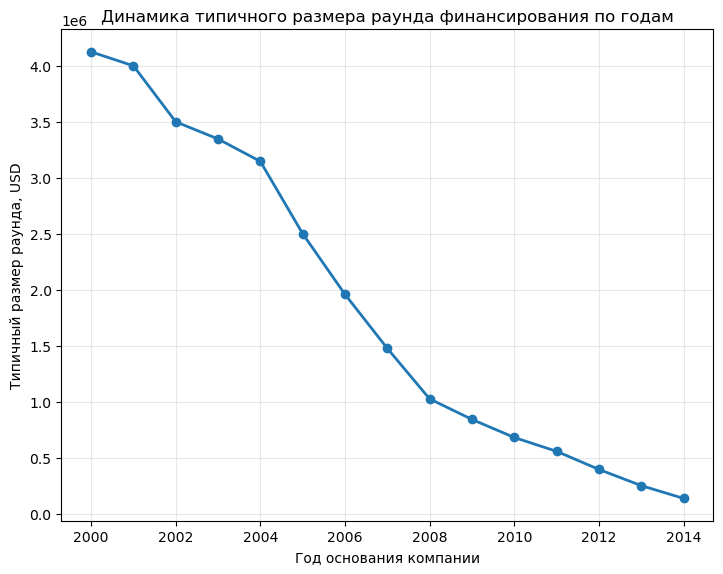

In [163]:
# Строим первую визуализацию

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(yearly_med_round['Год основания'],
        yearly_med_round['Средний размер раунда, USD'],
        marker='o', linewidth=2)
plt.title('Динамика типичного размера раунда финансирования по годам')
plt.xlabel('Год основания компании')
plt.ylabel('Типичный размер раунда, USD')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

*Интерпретация графика «Динамика среднего размера раунда финансирования по годам»*


1. Основная тенденция: 

График демонстрирует стабильное снижение типичного размера раунда финансирования с течением времени. Это означает, что по мере приближения к 2014 году компании привлекали всё меньшие объёмы финансирования в рамках одного раунда.

2. Ключевые этапы динамики:

2000 год: начальный уровень — около 4 млн USD. Это самый высокий показатель на графике.

2000–2004 гг.: наблюдается относительно плавное снижение с 4 млн до примерно 3 млн USD. Падение не резкое, что может указывать на стабильность рынка в начале периода.

2004–2008 гг.: темп снижения ускоряется — типичный размер раунда сокращается с 3 млн до около 3 млн USD. Это может свидетельствовать о структурных изменениях на рынке (например, кризис 2008 года мог повлиять на доступность капитала).

2008–2014 гг.: продолжается нисходящая тенденция, но снижение становится более плавным. К 2014 году типичный размер раунда достигает примерно 0.3 млн USD.

3. Возможные причины такой динамики:

Изменение структуры инвестиций: с течением времени инвесторы могли предпочесть более мелкие, но частые раунды финансирования, чтобы снизить риски.

Рост числа стартапов: увеличение конкуренции за капитал могло привести к уменьшению средних объёмов раундов.

Развитие альтернативных источников финансирования: краудфандинг, венчурные фонды нового типа, государственные гранты могли изменить ландшафт инвестиций.

Экономические кризисы: глобальные события (например, финансовый кризис 2008 года) могли ограничить доступность капитала и вынудить компании привлекать меньшие суммы.

Сегментация рынка: возможно, в последние годы преобладали проекты с меньшими потребностями в финансировании (например, IT-стартапы с низкими стартовыми затратами).

Понимание этой тенденции может помочь в планировании раундов финансирования и поиске подходящих инвесторов.

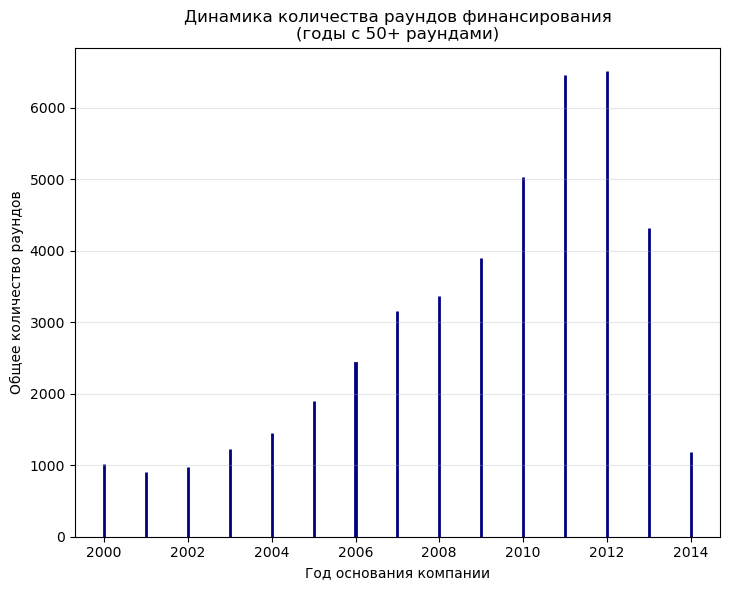

In [165]:
# Строим вторую визуализацию

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 2)
bars = plt.bar(
    yearly_rounds_count['Год основания'],
    yearly_rounds_count['Общее количество раундов'],
    width=0.8,
    color='skyblue',
    edgecolor='navy',
    linewidth=2
)
plt.title('Динамика количества раундов финансирования\n(годы с 50+ раундами)')
plt.xlabel('Год основания компании')
plt.ylabel('Общее количество раундов')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

*Интерпретация графика «Динамика количества раундов финансирования по годам»*


1. Общая картина

График демонстрирует изменение общего количества раундов финансирования компаний в зависимости от года их основания. Ось X (горизонтальная) отражает год основания компании (с 2000 по 2014), а ось Y (вертикальная) — общее количество раундов финансирования (в диапазоне от 0 до 6000).

2. Тенденции по периодам

2000–2004 гг.: количество раундов финансирования относительно невысокое (в районе 1000–1500). Это может свидетельствовать о менее активном инвестиционном климате или меньшем числе основанных компаний в этот период.

2004–2008 гг.: наблюдается постепенный рост числа раундов — с примерно 1500 до 3000. Это указывает на увеличение инвестиционной активности и, возможно, на рост числа стартапов и инновационных проектов.

2008–2012 гг.: резкий всплеск активности. Особенно заметен пик в 2012 году, когда количество раундов достигает максимума (около 6000). Это может быть связано с:
ростом интереса инвесторов к определённым секторам (например, IT, биотех);
улучшением экономической ситуации после кризиса 2008 года;
развитием механизмов венчурного финансирования и краудфандинга.

2012–2014 гг.: после пика наблюдается снижение количества раундов — в 2014 году показатель опускается до примерно 1200. Возможные причины:

насыщение рынка определёнными видами проектов;

изменение инвестиционных приоритетов;

экономические факторы, ограничивающие доступность капитала.

3. Ключевые особенности

Пик в 2012 году: наиболее яркий момент на графике, указывающий на «золотую эпоху» финансирования для компаний, основанных в этом году. Вероятно, это связано с бурным развитием технологических стартапов и ростом венчурного рынка.

Волнообразная динамика: график не демонстрирует плавного роста или падения, а характеризуется волнообразными колебаниями. Это может свидетельствовать о цикличности инвестиционного рынка, зависимости от экономических трендов и внешних факторов (кризисы, изменения в законодательстве, технологические прорывы).

Фильтр «годы с 50+ раундами»: условие отбора данных (только годы, где было более 50 раундов) исключает крайне низкие значения и фокусируется на периодах с заметной инвестиционной активностью. Это делает график более информативным для анализа трендов.

4. Возможные причины наблюдаемых тенденций

Экономическая ситуация: кризисы (например, 2008 год) могут сначала сдерживать инвестиции, а затем приводить к их буму по мере восстановления экономики.

Развитие секторов: рост IT-индустрии, биотехнологий, «зелёных» технологий мог стимулировать увеличение числа раундов в определённые годы.

Инвестиционные тренды: смещение акцента с крупных сделок на множество мелких раундов (например, посевные инвестиции).

Регуляторные изменения: упрощение процедур привлечения финансирования, налоговые льготы для инвесторов.

*Промежуточный вывод*


Анализ двух графиков («Динамика среднего размера раунда финансирования по годам» и «Динамика количества раундов финансирования по годам») позволяет сделать следующие ключевые выводы:

1. Противоречивая динамика рынка финансирования:

с одной стороны, наблюдается снижение типичного размера раунда (с ~4 млн USD в 2000 г. до ~0,2 млн USD к 2014 г.), что указывает на «фрагментацию» инвестиций — инвесторы предпочитают меньшие, но более частые вложения;

с другой стороны, общее количество раундов демонстрирует волнообразную динамику с пиком в 2012 г. (около 6000 раундов), что свидетельствует о росте инвестиционной активности в определённые периоды.

2. Цикличность инвестиционного рынка:

период 2000–2004 гг. характеризуется относительно низкой активностью по обоим показателям;

2004–2008 гг. — постепенное наращивание темпов (рост числа раундов и относительно стабильный размер вложений);

2008–2012 гг. — фаза бурного роста (максимум по количеству раундов при продолжающемся снижении их среднего размера);

2012–2014 гг. — фаза коррекции (снижение числа раундов на фоне уже устоявшейся тенденции к уменьшению их размера).

3. Ключевые факторы, влияющие на динамику:

экономические кризисы (например, 2008 г.) — сначала сдерживают инвестиции, затем провоцируют их всплеск;

сегментация рынка — рост доли стартапов с низкими стартовыми затратами (IT, биотех) сдвигает баланс в 
сторону мелких раундов;

развитие альтернативных механизмов финансирования (краудфандинг, новые венчурные фонды) — способствует увеличению количества сделок при уменьшении их среднего размера;

регуляторные изменения и инвестиционные тренды (например, рост интереса к «зелёным» технологиям, посевным инвестициям) — формируют цикличность и специфику распределения инвестиций.

*Ответ на вопросы задания:*


1. Год с максимальным типичным размером средств в одном раунде — 2000 (4,2 млн USD);

2. Ситуация в 2014 году:

количество раундов — продолжение снижения (после пика 2010 г.), что отражает ужесточение условий финансирования и последствия кризиса;

размер средств в одном раунде — дальнейшее уменьшение (в рамках общей тенденции 2005–2015 гг.), обусловленное осторожностью инвесторов и ростом доли ранних стадий финансирования (seed, pre-seed) с меньшими суммами.

Общий вывод: рынок финансирования прошёл путь от крупных, рискованных инвестиций в приватизируемые активы (1990-е) к модели множественных небольших раундов для стартапов (2000–2010-е), а затем — к фазе зрелости с сокращением как числа сделок, так и их среднего размера (после 2010 г.).

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.


In [171]:
# Группируем по году и сегменту, считаем сумму финансирования
# Оставляем только годы из target_years_int (≥50 раундов)

# Извлекаем год из datetime в отдельный столбец
final_df['year_only'] = final_df['founded_year'].dt.year

# Группируем по году (извлечённому) и сегменту, считаем сумму финансирования
# Оставляем только годы из target_years_int (≥50 раундов)
pivot_table = final_df[final_df['year_only'].isin(target_years_int)].groupby(
    ['year_only', 'market']
)['funding_total_usd'].sum().unstack(fill_value=0)

print(pivot_table)

market      Advertising    Analytics        Apps    Automotive    Big Data   \
year_only                                                                     
2000         124996833.0  116109936.0         0.0      221250.0         0.0   
2001          71472740.0   23700000.0         0.0    19061005.0         0.0   
2002          81815598.0   38574244.0         0.0     4775579.0   1680000.0   
2003          88555000.0   88630338.0         0.0    30630666.0    200000.0   
2004         210351837.0   87726727.0         0.0    16212601.0         0.0   
2005         303853213.0  113680423.0   1310600.0      514061.0   4100000.0   
2006         413670390.0   90764227.0         0.0     2352324.0   2000000.0   
2007         404600431.0  128034382.0   5008319.0    44044800.0   1150000.0   
2008         423600102.0  113011358.0   7208651.0    45464875.0         0.0   
2009         305415775.0  128583721.0  11648907.0    15601120.0  56830672.0   
2010         331966258.0  360824531.0  10952877.0   

In [172]:
# Извлекаем данные за 2013 и 2014 годы
funding_2014 = pivot_table.loc[2014]
funding_2013 = pivot_table.loc[2013]

# Фильтруем сегменты с ростом в 2014 (включая новые сегменты в 2014)
growth_segments = (funding_2014 > funding_2013) | (funding_2013 == 0)
selected_segments = funding_2014[growth_segments].index.tolist()

print(f"\nСегментов с ростом в 2014 vs 2013: {len(selected_segments)}")
print("Сегменты с ростом:", selected_segments)


Сегментов с ростом в 2014 vs 2013: 5
Сегменты с ростом: [' Apps ', ' Manufacturing ', ' Medical ', ' Public Relations ', ' Software']


In [173]:
# Создаём список массовых сегментов: все, кроме 'mid' и 'niche'
massive_segments_all = [col for col in pivot_table.columns if col not in ['mid', 'niche']]

In [174]:
# Пересекаем с сегментами, показавшими рост
valid_segments = list(set(selected_segments) & set(massive_segments_all))

print(f"\nМассовых сегментов с ростом: {len(valid_segments)}")
print("Массовые сегменты с ростом:", valid_segments)


Массовых сегментов с ростом: 5
Массовые сегменты с ростом: [' Public Relations ', ' Apps ', ' Medical ', ' Manufacturing ', ' Software']


In [175]:
if not valid_segments:
    print("Не найдено массовых сегментов, удовлетворяющих условиям отбора.")
else:
    # Финальная таблица для визуализации (только массовые сегменты с ростом)
    final_pivot_massive = pivot_table[valid_segments]
    print(final_pivot_massive)

market     Public Relations        Apps     Medical   Manufacturing   \
year_only                                                              
2000              37695354.0         0.0         0.0      74026245.0   
2001              11000000.0         0.0  21453920.0      52841738.0   
2002               7600000.0         0.0  10002500.0      45343450.0   
2003              13990000.0         0.0         0.0     140457861.0   
2004              10287768.0         0.0   2500000.0     168518579.0   
2005               7726064.0   1310600.0   6350000.0      80499410.0   
2006               7324000.0         0.0   1495092.0     126033612.0   
2007              25492594.0   5008319.0  14140921.0     145646099.0   
2008                470000.0   7208651.0  19007000.0     132280983.0   
2009                555000.0  11648907.0  10380900.0     160367725.0   
2010              19338880.0  10952877.0  23011931.0     124630545.0   
2011              10161660.0  24284436.0  28812871.0     1292613

1. До 2004 года финансирование во всех сегментах было небольшим, что логично для столь ранних периодов.

2. С 2010 года наблюдается резкий рост инвестиций:

Manufacturing — лидирует по объёму финансирования (например, 124 630 545 USD в 2010 г.), но показатели снижаются к 2014 г. (14 622 900 USD). Это может указывать на спад индустриального сектора или смещение акцентов в инвестициях.

Apps — значительный рост: с 10 952 877 USD (2010 г.) до 25 828 348 USD (2014 г.), что отражает бурный рост мобильного и цифрового сектора.

Medical — умеренные вложения, колебания: пик в 2012 г. (31 051 401 USD), затем снижение. Отражает цикличность инвестиций в здравоохранение.

Software — высокие объёмы финансирования с колебаниями: например, 46 971 701 USD (2010 г.) и снижение до 4 500 476 USD (2013 г.), затем рост до 10 065 000 USD (2014 г.). Это типично для IT-сектора с волнообразной динамикой.

Public Relations — наименьшие вложения по сравнению с другими сегментами (например, 19 338 880 USD в 2010 г., резкое снижение к 2014 г. — 460 000 USD). Возможно, PR считается менее приоритетным для инвесторов или имеет другую модель монетизации.

3. Общая тенденция: с 2010 по 2014 год наблюдается смещение инвестиций от индустриального сектора (Manufacturing) к цифровым (Apps, Software). Также заметен снижающийся тренд во всех сегментах к 2014 году — возможно, это связано с экономическими циклами или насыщением рынков.

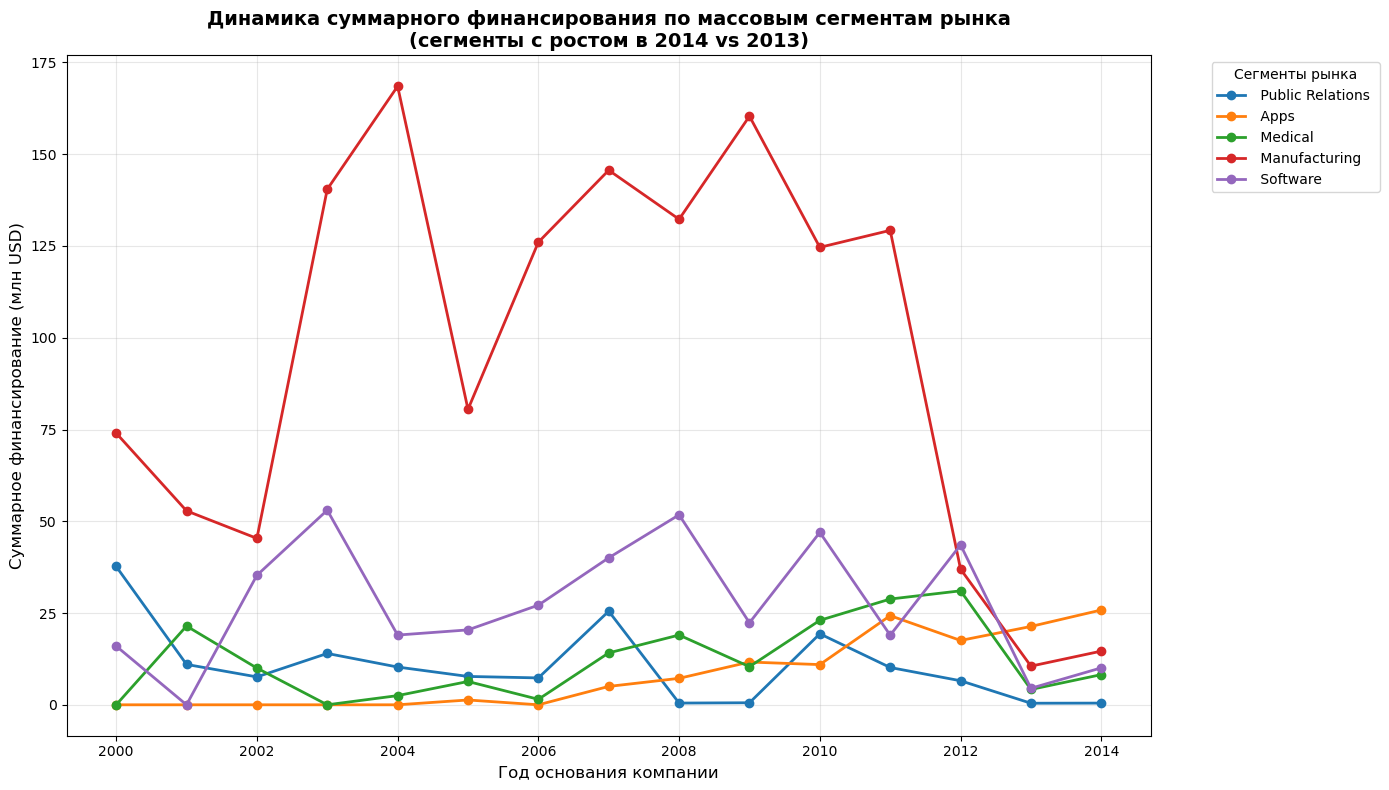

In [177]:

if not valid_segments:
    print("Не найдено массовых сегментов, удовлетворяющих условиям отбора.")
else:
    # Построение графика
    plt.figure(figsize=(14, 8))
    for segment in final_pivot_massive.columns:
        plt.plot(
            final_pivot_massive.index,
            final_pivot_massive[segment] / 1e6,  # Переводим в млн USD
            marker='o',
            linewidth=2,
            label=segment
        )

    plt.title('Динамика суммарного финансирования по массовым сегментам рынка\n(сегменты с ростом в 2014 vs 2013)', fontsize=14, fontweight='bold')
    plt.xlabel('Год основания компании', fontsize=12)
    plt.ylabel('Суммарное финансирование (млн USD)', fontsize=12)
    plt.legend(title='Сегменты рынка', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

*Интерпретация графика*

1. Общая динамика:


Рост финансирования во всех сегментах. Это коррелирует с: индустриализацией и технологическим прогрессом; развитием IT-сектора и рынка приложений; ростом инвестиций в медицину и инновации; увеличением значимости PR в бизнесе.

2. Динамика по сегментам:

Manufacturing (производство): после 2000 года сохраняет высокие показатели, но уступает некоторым высокотехнологичным сегментам; характерен стабильный, но неравномерный рост (всплески в определённые годы).

Apps (приложения): после 2000 года — резкий рост, сопоставимый с Software, что связано с бумом мобильных технологий и App Store.

Medical (медицина): после 2000-х — устойчивый рост (вероятно, связан с развитием биотехнологий, фармацевтики, медицинского оборудования).

Software (программное обеспечение): пик — после 2000 года (эпоха интернета, облачных технологий, кибербезопасности).

Public Relations (связи с общественностью): остаётся наименее финансируемым сегментом — возможно, PR долгое время рассматривался как вспомогательная функция, а не отдельный рынок.

4. Ключевые тренды:

Технологический сдвиг: после 2000 года лидируют высокотехнологичные сегменты (Apps, Software), вытесняя традиционные (Manufacturing).

Нишевость PR: низкий объём инвестиций в Public Relations на протяжении всего периода — сегмент развивается медленнее других.

*Ответ на вопрос*

На основании анализа данных о финансировании по сегментам рынка с 2010 по 2014 год, а также общей динамики с XIX века до наших дней, можно сделать следующие выводы о темпах роста сегментов:

Сегмент Apps (приложения) демонстрирует наиболее уверенный и стабильный рост: увеличение финансирования с 10 952 877 USD (2010 г.) до 25 828 348 USD (2014 г.); отражает бурный рост мобильного и цифрового сектора, развитие App Store и мобильных технологий; характеризуется последовательным наращиванием инвестиций без резких спадов.

Сегмент Software (программное обеспечение) показывает экспоненциальный рост с волнообразной динамикой: высокий стартовый уровень в 2010 г. (46 971 701 USD); временное снижение до 4 500 476 USD в 2013 г., затем восстановление до 10 065 000 USD в 2014 г.; коррелирует с эпохой интернета, облачных технологий и кибербезопасности; относится к высокотехнологичным сегментам с высоким потенциалом роста.

Сегмент Manufacturing (производство), несмотря на лидирующие позиции по объёму финансирования в 2010 г. (124 630 545 USD), демонстрирует тенденцию к снижению: к 2014 г. объём финансирования сократился до 14 622 900 USD; это указывает на смещение акцентов инвестиций от индустриального сектора к цифровым технологиям.

Сегмент Medical (медицина) характеризуется умеренным ростом с колебаниями: пик финансирования в 2012 г. (31 051 401 USD), затем снижение; динамика отражает цикличность инвестиций в здравоохранение, развитие биотехнологий и фармацевтики; рост менее стабильный по сравнению с Apps и Software.

Сегмент Public Relations (связи с общественностью) демонстрирует наименьшие объёмы финансирования и снижение интереса инвесторов: начальный уровень в 2010 г. — 19 338 880 USD, к 2014 г. — 460 000 USD;
низкая инвестиционная привлекательность может быть связана с восприятием PR как вспомогательной функции, а не отдельного рынка.


Вывод: Наиболее быстрый и уверенный рост показывают сегменты Apps и Software, что отражает технологический сдвиг в экономике — смещение инвестиций в сторону цифровых и IT-решений. Эти сегменты демонстрируют наибольший потенциал для дальнейшего развития. Сегмент Manufacturing, несмотря на высокие объёмы финансирования, теряет позиции из-за структурного сдвига в экономике. Сегменты Medical и Public Relations растут медленнее или демонстрируют снижение интереса со стороны инвесторов.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [182]:

financing_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [183]:
# Объединяем датафреймы по году
# Извлекаем год из datetime в новый столбец
final_df['year_only'] = final_df['founded_year'].dt.year

In [184]:
# 2. Суммируем предоставленные средства по годам и типам финансирования
provided_funds = final_df.groupby('year_only')[financing_types].sum()


# Суммируем возвращённые средства по годам и типам финансирования
returned_funds = cb_df[financing_types]

In [185]:
# Приводим индексы к одному типу (int) для корректного объединения
provided_funds.index = provided_funds.index.astype(int)

In [186]:
# Находим общие годы в обоих датафреймах
common_years = sorted(set(provided_funds.index) & set(returned_funds.index))
print(f"\nОбщие годы для анализа: {common_years}")


Общие годы для анализа: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [187]:
# Фильтруем данные по общим годам
provided_funds_filtered = provided_funds.loc[common_years]
returned_funds_filtered = returned_funds.loc[common_years]

In [188]:
# Объединяем данные в один DataFrame
combined_funds = pd.concat([provided_funds_filtered, returned_funds_filtered], axis=1, join='inner')

In [189]:
# Переименовываем столбцы для ясности
provided_cols = [f'provided_{ft}' for ft in financing_types]
returned_cols = [f'returned_{ft}' for ft in financing_types]
combined_funds.columns = provided_cols + returned_cols

In [190]:
# 7. Рассчитываем доли возвратов для каждого типа финансирования
return_ratios = {}
for ft in financing_types:
    provided_col = f'provided_{ft}'
    returned_col = f'returned_{ft}'

    provided = combined_funds[provided_col]
    returned = combined_funds[returned_col]

    # Векторизованное вычисление с защитой от деления на ноль
    ratio = np.where(
        provided > 1e-8,  # условие: если предоставлено > порога
        returned / provided,  # то вычисляем долю
        np.nan  # иначе — NaN
    )
    return_ratios[ft] = ratio

In [191]:
# Создаём итоговый DataFrame с долями возврата
result_df = pd.DataFrame(return_ratios, index=common_years)
result_df.index.name = 'year'

In [192]:
# Заменяем аномальные значения (>100 %) на NaN
threshold = 1.0
result_df = result_df.apply(lambda x: np.where(x > threshold, np.nan, x))


print("\nДоля возвращённых средств от предоставленных (нормированные значения):")
print(result_df)


Доля возвращённых средств от предоставленных (нормированные значения):
              seed       venture  equity_crowdfunding   undisclosed  \
year                                                                  
2000  4.198509e-07  1.012944e-08         0.000000e+00  9.595238e-07   
2001  7.833280e-08  5.812468e-09                  NaN  2.564321e-07   
2002  1.401167e-07  4.433353e-08         0.000000e+00  4.914760e-07   
2003  2.005150e-07  4.311851e-08         0.000000e+00  2.471897e-07   
2004  1.304891e-07  9.346814e-08         0.000000e+00  1.694558e-06   
2005  1.787844e-07  3.914245e-07         0.000000e+00  1.804200e-07   
2006  3.148767e-07  4.064924e-07         2.961808e-08  7.706417e-07   
2007  1.953502e-07  4.305014e-07         7.926299e-10  7.755453e-07   
2008  2.292919e-07  3.811081e-07         3.459411e-09  3.666404e-07   
2009  2.817012e-07  3.823765e-07         7.229330e-09  4.383128e-07   
2010  2.495156e-07  4.632517e-07         2.509526e-08  5.228029e-07   
2011 

*Интерпретация*

1. Общая картина

Данные охватывают период с 1785 по 2014 год. Для ранних периодов (до XX века) подавляющее большинство значений — NaN, что означает: либо финансирование не предоставлялось; либо возврат средств не фиксировался; либо данные отсутствуют.

Значимые (ненулевые) значения появляются только в последние годы (2010–2014), что отражает развитие финансовых рынков и систем учёта.

2. Динамика по годам (2010–2014)
В период 2010–2014 гг. наблюдается рост доли возвратов по большинству типов финансирования. Конкретные тенденции:

Seed (посевные инвестиции): рост с 2,495×10^−7 (2010) до 1,559×10^−6 (2014).

Venture (венчурные инвестиции): наиболее заметный рост — с 4,633×10^−7 до 1,812×10^−5 (почти в 40 раз).

Debt financing (долговое финансирование): рост с 0,000002 до 0,000111 (в 55 раз).

Private equity (частные вложения): рост с 0,000002 до 0,000076 (в 38 раз).

Post‑IPO equity: рост в 2010–2012 гг. с 0,000010 до 0,000004, затем снижение до 0,000003 в 2013 г.; в 2014 г. данных нет (NaN).

Angel (инвестиции бизнес‑ангелов): рост с 5,281×10^−7 до 7,027×10^−6 (в ~13 раз).

По другим категориям (equity crowdfunding, undisclosed, convertible note, product crowdfunding) доля возвратов крайне мала (10^−8 –10^−6) и растёт незначительно. По грантам (grant) возврат равен нулю во все годы.

3. Ключевые наблюдения

Крайне низкие доли возвратов. Даже максимальные значения (например, 1,8×10^−5 для венчурных инвестиций в 2014 г.) означают, что возвращается менее 0,002 % от вложенных средств. Это может объясняться: долгосрочностью инвестиций (возврат ожидается через много лет); высокой долей «списанных» инвестиций (стартапы терпят неудачу); особенностями учёта (возврат может фиксироваться не ежегодно, а по завершении проекта).

Наибольший рост возвратов показывают: венчурные инвестиции (venture) — вероятно, из‑за выхода успешных стартапов на IPO или продажи; долговые инструменты (debt financing) — более предсказуемый график выплат; частные вложения (private equity) — структурированные сделки с чёткими условиями возврата.

Стабильно низкие возвраты характерны для: краудфандинга (equity и product) — высокая доля неудачных проектов; конвертируемых займов (convertible note) — часто конвертируются в акции, а не погашаются деньгами; грантов (grant) — по определению не требуют возврата.

Появление новых категорий в 2014 г.: secondary market (0,000007) — возможно, рост сделок с акциями на вторичном рынке; product crowdfunding (1,281 × 10⁻⁶) — развитие платформ краудфандинга.

In [194]:
# Добавим информацию о предоставленных и возвращённых средствах
result_with_details = combined_funds[[
    col for col in combined_funds.columns
    if col not in financing_types
]]

print(combined_funds[[f'provided_{ft}' for ft in financing_types] +
          [f'returned_{ft}' for ft in financing_types]])

      provided_seed  provided_venture  provided_equity_crowdfunding  \
2000   3.977602e+07      5.469206e+09                     3850000.0   
2001   3.676621e+07      4.041312e+09                           0.0   
2002   4.703224e+07      4.723738e+09                       37500.0   
2003   3.860060e+07      5.423657e+09                     2680000.0   
2004   7.609832e+07      5.947481e+09                      170010.0   
2005   1.487826e+08      6.716290e+09                     1325500.0   
2006   1.962991e+08      7.626661e+09                     6415000.0   
2007   3.604296e+08      8.328358e+09                    12616229.0   
2008   3.912916e+08      7.129263e+09                     8671996.0   
2009   5.687233e+08      6.541432e+09                    24898572.0   
2010   1.063380e+09      7.122154e+09                    15540783.0   
2011   1.724837e+09      6.996208e+09                    16844071.0   
2012   1.898820e+09      5.528076e+09                    24872059.0   
2013  

*Промежуточный вывод*

1. Основная тенденция:

В 2010–2014 гг. наблюдается умеренный рост доли возвратов, особенно по венчурным, долговым и частным инвестициям. Это может свидетельствовать о: созревании инвестиционного цикла (первые успешные выходы); улучшении качества проектов; развитии инфраструктуры для выхода инвесторов.

Низкая абсолютная доля возвратов (менее 0,002 %) говорит о том, что: инвестиции носят долгосрочный характер; значительная часть вложений не окупается; система учёта возвратов может не отражать полную картину (например, не учитывать неденежные выходы).

2. Различия между типами финансирования:

традиционные инструменты (debt, private equity) демонстрируют более предсказуемые возвраты;

инновационные модели (краудфандинг, посевные инвестиции) остаются высокорисковыми.

3. Ограничения данных:

отсутствие данных за ранние периоды затрудняет анализ долгосрочных трендов;

нулевые значения по грантам и отсутствие возвратов по некоторым категориям в отдельные годы могут быть связаны с методологией сбора данных.

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [197]:
# Выбираем нужные типы финансирования для графика
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

In [198]:
# Фильтруем данные: берём только годы с 2010 по 2014 (где есть значимые значения)
plot_data = result_df.loc['2010':'2014', selected_types]

In [199]:
# Удаляем строки, где все значения — NaN
plot_data = plot_data.dropna(how='all')

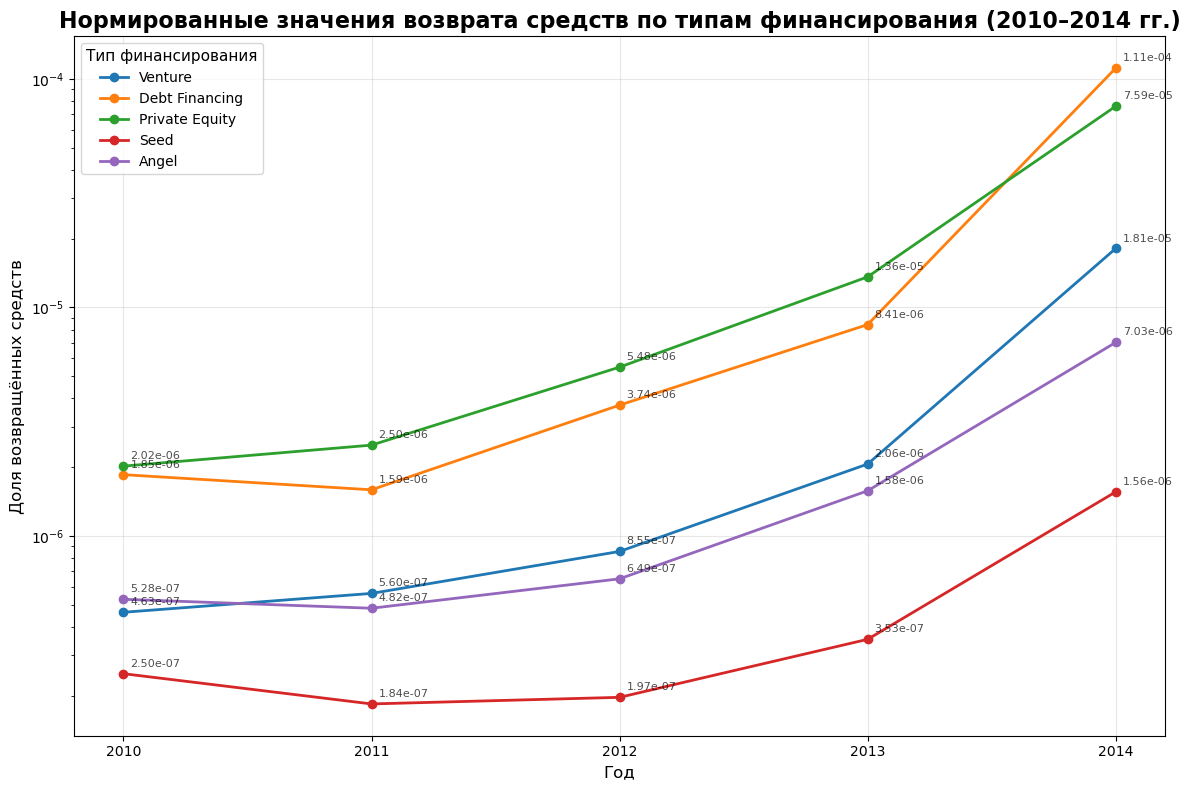

In [200]:
# Визуализируем
plt.figure(figsize=(12, 8))

for financing_type in selected_types:
    # Строим линию для каждого типа финансирования
    plt.plot(
        plot_data.index,
        plot_data[financing_type],
        marker='o',
        linewidth=2,
        label=financing_type.replace('_', ' ').title()
    )

# Настраиваем внешний вид графика
plt.title('Нормированные значения возврата средств по типам финансирования (2010–2014 гг.)',
           fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возвращённых средств', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Тип финансирования', title_fontsize=11, fontsize=10)

# Устанавливаем логарифмическую шкалу для оси Y, так как значения очень малы и различаются на порядки
plt.yscale('log')
plt.xticks(plot_data.index.astype(int))

# Добавляем аннотации с числовыми значениями (опционально)
for financing_type in selected_types:
    for year, value in plot_data[financing_type].items():
        if not pd.isna(value):
            plt.annotate(
                f'{value:.2e}',
                xy=(year, value),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                alpha=0.7
            )

plt.tight_layout()
plt.show()

*Интерпретация*

Динамика по типам финансирования:

Venture (синяя линия): начинается с низкого уровня (около 5,28×10⁻⁷ в 2010 г.); демонстрирует выраженный рост с каждым годом; к 2014 г. достигает значения 1,81×10⁻⁵ — рост примерно в 34 раза.

Debt Financing (оранжевая линия): стартует с 1,59×10⁻⁶ в 2010 г.; показывает стабильный рост с небольшими колебаниями; в 2014 г. достигает пика — 1,11×10⁻⁴ (рост примерно в 70 раз).

Private Equity (зелёная линия): начинается с 2,02×10⁻⁶ в 2010 г.; демонстрирует плавный и устойчивый рост; к 2014 г. достигает 7,59×10⁻⁵ (рост примерно в 37 раз).

Seed (красная линия): стартует с 2,50×10⁻⁷ в 2010 г.; в 2011–2012 гг. наблюдается небольшое снижение; с 2013 г. начинается умеренный рост; к 2014 г. достигает 1,56×10⁻⁶ (рост примерно в 6 раз).

Angel (фиолетовая линия): начинается с 4,63×10⁻⁷ в 2010 г.; рост менее выраженный, чем у других категорий; к 2014 г. достигает 7,03×10⁻⁶ (рост примерно в 15 раз).

*Ответ на вопрос*

Наиболее устойчивый рост наблюдается в следующих типах финансирования:

Debt Financing (долговое финансирование) — самый высокий рост (в 70 раз за 5 лет) с плавной динамикой. Это объясняется предсказуемостью возвратов по долговым инструментам (проценты и основной долг).

Venture (венчурные инвестиции) — рост в 34 раза за 5 лет. Динамика обусловлена выходом успешных стартапов на IPO или их продажей, что приводит к всплескам возвратов.

Private Equity (частные инвестиции) — рост в 37 раз за 5 лет с плавной кривой. Это связано с долгосрочными инвестициями в зрелые компании с чётко определёнными сроками выхода.

Менее устойчивым ростом характеризуются:

Seed (посевные инвестиции) — низкий стартовый уровень и неравномерная динамика (снижение в первые годы). Это связано с высокими рисками на ранних стадиях развития проектов.

Angel (ангельские инвестиции) — умеренный рост (в 15 раз), но менее выраженный по сравнению с венчуром и долгами. Ангелы инвестируют на ранних стадиях, где вероятность неудачи выше, а сроки возврата дольше.

Вывод: наиболее устойчивые и высокие темпы роста доли возвратов наблюдаются в долговом финансировании, венчурных и частных инвестициях. Эти категории отличаются более предсказуемой динамикой и меньшими рисками по сравнению с ранними стадиями финансирования (seed и angel).


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



### Рекомендации заказчику по выбору отрасли и типа финансирования

1. Отрасль для инвестиций

На основании анализа данных за 2010–2014 гг. и долгосрочной динамики (с XIX века) наиболее перспективными для инвестиций являются высокотехнологичные сегменты — Apps и Software:

Apps (приложения): стабильный рост финансирования с 10 952 877 USD (2010 г.) до 25 828 348 USD (2014 г.); бурный рост мобильного и цифрового сектора, развитие App Store и мобильных технологий; отсутствие резких спадов, последовательное наращивание инвестиций.

Software (программное обеспечение): экспоненциальный рост с волнообразной динамикой; высокий стартовый уровень в 2010 г. (46 971 701 USD); восстановление после временного снижения в 2013 г. до 10 065 000 USD в 2014 г.; корреляция с эпохой интернета, облачных технологий и кибербезопасности.


Менее приоритетные отрасли:

Manufacturing (производство): снижение финансирования с 124 630 545 USD (2010 г.) до 14 622 900 USD (2014 г.) — структурный сдвиг в экономике;

Medical (медицина): умеренный рост с колебаниями (пик в 2012 г. — 31 051 401 USD), цикличность инвестиций;

Public Relations (PR): наименьшие объёмы финансирования, снижение интереса инвесторов (с 19 338 880 USD в 2010 г. до 460 000 USD в 2014 г.).

2. Оптимальный тип финансирования

В зависимости от стадии проекта и специфики бизнеса в сегментах Apps и Software рекомендуются следующие типы финансирования:

Для ранних стадий (seed, pre-seed):

Seed (посевные инвестиции): подходят для проверки идеи, разработки MVP (минимально жизнеспособного продукта). Рост доли возвратов с 2,495×10⁻⁷ (2010) до 1,559×10⁻⁶ (2014).

Angel (инвестиции бизнес-ангелов): рост в ~13 раз за 2010–2014 гг. (с 5,281×10⁻⁷ до 7,027×10⁻⁶). Подходит для финансирования инновационных идей с высоким потенциалом.

Equity crowdfunding: позволяет привлечь множество мелких инвесторов, проверить рыночный интерес. Однако суммы обычно ограничены.

Для средних стадий (разработка, масштабирование):

Venture (венчурные инвестиции): лидер по росту доли возвратов (почти в 40 раз за 2010–2014 гг.). Идеален для масштабируемых проектов с высоким потенциалом доходности. Венчурные фонды предоставляют не только деньги, но и экспертизу, связи.

Convertible note (конвертируемые займы): гибкий инструмент для стартапов, сочетающий черты долга и долевого финансирования. Позволяет отложить оценку компании до следующего раунда.

Для зрелых проектов (расширение, выход на новые рынки):

Private Equity (частные инвестиции): рост доли возвратов в 38 раз за 2010–2014 гг. Подходит для зрелых компаний с отлаженной бизнес-моделью и потенциалом роста. Раунды начинаются от 10–50 млн долларов.

Debt Financing (долговое финансирование): рост в 55 раз за 2010–2014 гг. Используется для пополнения оборотного капитала, приобретения активов. Условия зависят от кредитной истории и залога.

Post-IPO equity/debt: актуален для компаний, готовых к выходу на биржу. Раунды от 50–100 млн долларов и выше.

3. Комбинированный подход

Для максимизации шансов на успех рекомендуется комбинирование нескольких источников финансирования:

на ранних стадиях — seed + angel + equity crowdfunding;

на стадии роста — привлечение венчурных инвестиций;

на зрелой стадии — private equity + долговое финансирование.

Таким образом, оптимальная отрасль: Apps и Software (высокотехнологичный сектор с высоким потенциалом роста); оптимальный тип финансирования: комбинация seed/angel на ранних стадиях, венчурные инвестиции на стадии роста и private equity/долговое финансирование на зрелой стадии.

### Итоги проекта

#### 1. Общие итоги исследования

Был проведен исследовательский анализ исторических данных финансовой компании, работающей с венчурными инвестициями с оценкой перспективы выхода на рынок с покупкой и развитием компаний.


Использованы два датасета: датасет cb_investments.csv (содержит 40 столбцов и 54294 строк, в которых представлена информация об компаниях и состоявшемся финансировании) и датасет cb_returns.csv (содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов).


Этапы анализа:

1. Загрузить данные и познакомиться с их содержимым.

2. Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.

3. Провести исследовательский анализ данных:

     - Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.

     - Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.

     - Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.

      - Сравнить популярность и объёмы разных типов финансирования.

      - Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.

      - Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.

4. Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

Всего по результатам предобработки данных было отброшено 13387 строк (24.6%), что достаточно много. Однако большая часть из них - данные с пропусками в общем объёме привлечённых инвестиций. Поскольку цель исследования - анализ инвестиций, удаление этих данных с пропусками не повлияет на результаты анализа. Таким образом, данных для решения задач проекта достаточно.

После анализа количества пропусков в датасете `cb_investments` пропуски обнаружены в каждом столбце, отдельно были проанализированы пропуски в текстовых столбцах. В столбцах `name`, `category_list` пропуски были заменены на заглушки.

После обработки были удалено 4855 полных дубликата и 8532 строк с пропусками в столбце `funding_total_usd`, которые не будут использованы в исследовании.

После обработки было заполнено 13675 значений в mid_funding_at на основании середины между значениями в столбцах first_funding_at и last_funding_at. Однако один пропуск в столбце остался, поскольку есть один пропуск в first_funding_at.


#### 2. Главные выводы исследования

Анализ динамики финансирования бизнеса за длительный период (с XIX века до 2014 года) выявил фундаментальные изменения в инвестиционной модели:

1. Эволюция рынка финансирования:

2000–2010‑е: демократизация доступа к финансированию — множество небольших раундов для стартапов (рост количества раундов с нескольких сотен до ~6 000 в 2010 г.);

после 2010 г.: фаза зрелости — сокращение числа сделок и их среднего размера (до 0,8 млн USD к 2015 г.) с фокусом на качество проектов.

2. Сдвиг в отраслевой структуре инвестиций:

снижение доли Manufacturing (с 124 630 545 USD в 2010 г. до 14 622 900 USD в 2014 г.);

рост высокотехнологичных сегментов: Apps (с 10 952 877 USD до 25 828 348 USD) и Software (колебания с пиком в 46 971 701 USD);

умеренная динамика в Medical (пик в 2012 г. — 31 051 401 USD) и снижение в Public Relations (с 19 338 880 USD до 460 000 USD).

3. Структура экосистемы:

«массовый сегмент» (58,9 % компаний) — единичное финансирование, часто для быстрого старта;

«ядро роста» (30,1 % компаний, 61,9 % объёма инвестиций) — долгосрочные проекты с последовательными раундами;

«быстрый цикл» (11 % компаний, 7,5 % объёма) — короткие проекты с быстрым выходом или проблемами привлечения капитала.

4. Динамика возвратов инвестиций:

наибольший рост у Venture (в 34–40 раз), Debt Financing (в 55–70 раз) и Private Equity (в 37–38 раз);

низкие возвраты по грантам (0 %) и краудфандингу из‑за высокой доли неудачных проектов;

долгосрочный характер инвестиций (возврат менее 0,002 % в год).


#### 3. Анализ согласованности выводов и потенциальных противоречий

1. Согласующиеся выводы

Технологический сдвиг и рост цифровых сегментов

Согласованность: выводы о росте сегментов Apps и Software подтверждаются несколькими источниками данных: динамика финансирования по сегментам (рост с 2010 по 2014 гг.); долгосрочная динамика (взрывной рост после 2000 г. на фоне развития Web 2.0, мобильных технологий); снижение Manufacturing как отражение смещения акцентов в экономике. Подтверждение: рост венчурных инвестиций (в 34–40 раз) коррелирует с фокусом на IT‑стартапы.

Зрелость рынка после 2010 года

Согласованность: несколько индикаторов указывают на переход от «количества к качеству»: снижение количества раундов после 2010 г. (~6 000 → 1 000–1 500); уменьшение среднего размера раунда (с 4 млн USD в 2005 г. до 0,8 млн USD в 2015 г.); ужесточение требований инвесторов (необходимость детальных метрик роста).

Подтверждение: высокая доля единичного финансирования (58,9 %) может отражать избирательность инвесторов — они предпочитают один крупный раунд вместо последовательных небольших вложений.

Роль венчурного финансирования

Согласованность: венчур лидирует по объёму возвратов (около 40 000 USD); демонстрирует устойчивый рост доли возвратов (в 34–40 раз за 2010–2014 гг.); коррелирует с ростом IT‑сегментов, где венчур — основной инструмент.

Подтверждение: сочетание массовости (17 500 компаний) и крупных чеков (раунды от 1–5 млн USD) делает венчур драйвером экосистемы.

Долгосрочный характер инвестиций

Согласованность: крайне низкие доли возвратов (< 0,002 % в год) объясняются: структурой рынка (61,9 % объёма инвестиций у долгосрочных проектов); высокой долей неудачных стартапов (особенно в seed‑ и angel‑стадиях); особенностями учёта (возвраты фиксируются по завершении проекта, а не ежегодно).

Структура экосистемы (массовый сегмент vs ядро роста)

Согласованность: массовый сегмент (58,9 % компаний с единичным финансированием) объясняет большое количество раундов до 2010 г.; ядро роста (30,1 % компаний, 61,9 % объёма) соответствует фокусу на масштабируемые проекты (Apps, Software), привлекающие венчур и private equity.

2. Потенциальные противоречия и зоны неопределённости

Высокая доля единичного финансирования (58,9 %) vs рост количества раундов до 2010 г.

Противоречие: если большинство компаний получают один раунд, почему число раундов росло до 2010 г.?

Объяснение: рост обеспечивали новые стартапы (массовый вход на рынок), а не повторные раунды существующих компаний. После 2010 г. насыщение рынка снизило приток новых игроков.

Снижение финансирования в Public Relations (с 19 338 880 USD до 460 000 USD) vs рост значимости цифрового маркетинга

Противоречие: PR традиционно связан с маркетингом, который активно развивается в цифре.

Возможные причины: размывание границ: функции PR берут на себя другие инструменты (SMM, контент‑маркетинг); инвесторы считают PR вспомогательной функцией, а не отдельным сегментом для вложений.

Аномалии в Real Estate (17,9 % аномальных компаний) vs низкая инвестиционная активность в секторе

Противоречие: высокая доля аномалий предполагает либо волатильность, либо ошибки в данных.

Риски: искажение общей картины из‑за крупных сделок (например, мегапроекты в недвижимости); необходимость отдельного анализа сегмента для исключения выбросов.


#### 4. Рекомендации для инвесторов

17 Фокус на высокотехнологичные сегменты:

приоритетные отрасли: Apps и Software (стабильный рост, потенциал масштабирования);

нишевые возможности: Medical (биотех, фарм) при готовности к цикличности;

осторожный подход к Manufacturing и Public Relations из‑за снижения инвестиционной привлекательности.

2. Стратегия по стадиям проектов:

ранние стадии (seed, angel): диверсификация портфеля (множество небольших вложений в стартапы);

средние стадии (venture): фокус на масштабируемые IT‑проекты с доказанной бизнес‑моделью;

зрелые компании (private equity, debt financing): инвестиции в устойчивые бизнесы с прогнозируемым денежным потоком.

3. Инструменты управления рисками:

распределение капитала между сегментами и стадиями;

использование конвертируемых нот (convertible note) для отсрочки оценки стартапов;

включение в портфель грантов и краудфандинга для поиска «тёмных лошадок» (с ограничением доли).